# SeamlessM4T v2 Large → 500M Multilingual Compression
## 5 Languages (EN/BN/ZH/AR/HI) · Voice Cloning · On-Device Mobile Target

### Compression Pipeline
| Phase | Technique | Target | Expected Savings |
|-------|-----------|--------|-----------------|
| 0 | Baseline benchmark (multilingual) | reference | — |
| 1 | Vocabulary pruning (5-lang, 256K→58K) | Asahi EMNLP 2023 | −215M |
| 2 | Pre-pruning multilingual activation analysis | Bidirectional SMC | — |
| 3 | Text decoder iterative pruning 24→6 layers | Moslem IWSLT 2025 | −651M |
| 4 | Speech encoder iterative pruning 24→8 layers | ShortGPT ACL 2025 | −423M |
| 5 | T2U iterative pruning 12→8 layers (ASR-ChrF) | Phase 6 adapted | −88M |
| 6 | KD data generation (offline teacher pass) | Moslem IWSLT 2025 | — |
| 7a | DoRA S2TT recovery fine-tuning | DoRA ICML 2024 | quality ↑ |
| 7b | T2U focused DoRA (unit cross-entropy) | DoRA ICML 2024 | audio ↑ |
| 8 | Final benchmark + paper table | — | — |

**Total target: ~491M params from 1805M (72.8% reduction)**

---
### ⚡ Session Resume Guide
All setup cells (this section) must run every session. Each Phase loads from Drive → runs → saves to Drive. 
To resume from Phase N: run all setup cells, then start at Phase N directly.


## ═══ SETUP SECTION — Run Every Session ═══

In [1]:
import os, sys, subprocess, pathlib, re, glob, json, gc, copy, time, math, shutil
import warnings; warnings.filterwarnings('ignore')

ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = not ON_KAGGLE
PLATFORM  = 'kaggle' if ON_KAGGLE else 'colab'

GDRIVE_MOUNT = '/content/drive/MyDrive/sm500'
KAGGLE_WORK  = '/kaggle/working'
WORK_DIR  = KAGGLE_WORK  if ON_KAGGLE else GDRIVE_MOUNT
CKPT_DIR  = f'{WORK_DIR}/checkpoints'
AUDIO_DIR = f'{WORK_DIR}/audio'
FIG_DIR   = f'{WORK_DIR}/figures'
MODEL_DIR = f'{WORK_DIR}/models'
GDRIVE_ROOT = 'gdrive:sm500'

# ── 5-language config ─────────────────────────────────────────────────────────
# SMC eval: 5 samples per pair × 8 pairs = 40 probes per candidate
N_SMC_PER_PAIR = 10

LANG_PAIRS = [
    # (fleurs_src,         fleurs_tgt,          m4t_src, m4t_tgt)
    ("en_us",             "bn_in",              "eng",   "ben"),
    ("en_us",             "cmn_hans_cn",        "eng",   "cmn"),
    ("en_us",             "ar_eg",              "eng",   "arb"),
    ("en_us",             "hi_in",              "eng",   "hin"),
    ("bn_in",             "en_us",              "ben",   "eng"),
    ("cmn_hans_cn",       "en_us",              "cmn",   "eng"),
    ("ar_eg",             "en_us",              "arb",   "eng"),
    ("hi_in",             "en_us",              "hin",   "eng"),
]

# Primary EN→BN benchmarking config (kept for backward compat)
TARGET_LANG    = "ben"
FLEURS_SRC     = "en_us"
FLEURS_TGT     = "bn_in"
N_EVAL         = 25

print(f'Platform : {PLATFORM}')
print(f'Work dir : {WORK_DIR}')
print(f'Lang pairs: {len(LANG_PAIRS)} bidirectional')


Platform : kaggle
Work dir : /kaggle/working
Lang pairs: 8 bidirectional


In [2]:
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print(f'Drive mounted: {GDRIVE_MOUNT}')
else:
    print('Kaggle: skipping Drive mount.')

for d in [WORK_DIR, CKPT_DIR, AUDIO_DIR, FIG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)
print('Directories ready.')


Kaggle: skipping Drive mount.
Directories ready.


In [3]:
if ON_KAGGLE:
    subprocess.run('curl -s https://rclone.org/install.sh | sudo bash',
                   shell=True, capture_output=True)
    ver = subprocess.run('rclone version', shell=True, capture_output=True, text=True)
    print(ver.stdout.split('\n')[0])
else:
    print('Colab: rclone not needed.')


rclone v1.73.5


In [4]:
def _get_secret(key):
    if ON_KAGGLE:
        try:
            from kaggle_secrets import UserSecretsClient
            return UserSecretsClient().get_secret(key)
        except Exception as e:
            raise RuntimeError(f'Kaggle secret {key!r}: {e}')
    else:
        try:
            from google.colab import userdata
            return userdata.get(key)
        except Exception as e:
            raise RuntimeError(f'Colab secret {key!r}: {e}')

if ON_KAGGLE:
    RCLONE_CONF = _get_secret('RCLONE_CONF')
    raw = RCLONE_CONF.strip()
    raw = re.sub(r'\s*(\[[^\]]+\])\s*', r'\n\1\n', raw)
    raw = re.sub(r'\s+(type|scope|token|team_drive|client_id|client_secret|'
                 r'root_folder_id|service_account_file|drive_id)\s*=\s*',
                 r'\n\1 = ', raw)
    raw = raw.strip() + '\n'
    rclone_cfg = pathlib.Path.home() / '.config/rclone/rclone.conf'
    rclone_cfg.parent.mkdir(parents=True, exist_ok=True)
    rclone_cfg.write_text(raw)
    r = subprocess.run('rclone lsd gdrive:', shell=True, capture_output=True, text=True)
    print('Drive root OK' if r.returncode == 0 else f'rclone FAILED: {r.stderr[:200]}')
    print(r.stdout[:300])


Drive root OK
           0 2026-04-11 05:42:37        -1 .ipynb_checkpoints
           0 2026-04-17 11:03:10        -1 Colab Notebooks
           0 2025-11-10 11:33:43        -1 ScholarMate
           0 2026-04-05 12:59:09        -1 cse465
           0 2026-04-12 12:42:04        -1 cse465v5
           0 2026-04-1


In [5]:
subprocess.run([
    'pip', 'install', '-q',
    'transformers', 'datasets', 'torchaudio', 'speechbrain',
    'peft', 'librosa', 'jiwer', 'evaluate', 'sacrebleu',
    'sentencepiece', 'accelerate', 'matplotlib', 'seaborn', 'safetensors',
], check=True)
print('All packages installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 43.6 MB/s eta 0:00:00
All packages installed.


In [6]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, matplotlib, seaborn as sns
import io, soundfile as sfile, torchaudio, pandas as pd
from datetime import datetime
from sacrebleu.metrics import BLEU, CHRF
from IPython.display import Audio as IPAudio, display

matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
sns.set_style('whitegrid')

_bleu = BLEU(effective_order=True)
_chrf = CHRF()

def count_params(module): return sum(p.numel() for p in module.parameters()) / 1e6

def count_params_detailed(model):
    bd = {name: count_params(child) for name, child in model.named_children()}
    bd['TOTAL'] = count_params(model)
    return bd

def print_model_breakdown(model, title='Model Breakdown'):
    bd = count_params_detailed(model)
    print(f'\n--- {title} ---')
    total = bd.pop('TOTAL')
    for name, p in sorted(bd.items(), key=lambda x: -x[1]):
        pct = p / total * 100 if total > 0 else 0
        print(f'  {name:<35} {p:>8.1f}M  ({pct:>5.1f}%)')
    print(f'  {"TOTAL":<35} {total:>8.1f}M')
    print('---')
    return {**bd, 'TOTAL': total}

def gpu_mem():
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved() / 1e9
        print(f'  GPU mem: {a:.2f} GB alloc / {r:.2f} GB reserved')

def compute_bleu(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _bleu.sentence_score(hyp.strip(), [ref.strip()]).score

def compute_chrf(hyp, ref):
    if not hyp.strip() or not ref.strip(): return 0.0
    return _chrf.sentence_score(hyp.strip(), [ref.strip()]).score

def find_layers_attr(component):
    for attr in ['layers', 'layer', 'inner_layers', 'encoder_layers', 'decoder_layers']:
        if hasattr(component, attr): return attr
    return None

def play(audio, sr, label=''):
    if hasattr(audio, 'numpy'): audio = audio.squeeze().numpy()
    print(f'  {label}  ({len(audio)/sr:.1f}s | sr={sr})')
    display(IPAudio(audio, rate=int(sr)))

def save_figure(fig, name):
    path = f'{FIG_DIR}/{name}'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    if ON_KAGGLE:
        subprocess.run(f'rclone copy "{path}" "{GDRIVE_ROOT}/figures/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                       shell=True, capture_output=True)

def save_audio(audio, sr, filename):
    path = f'{AUDIO_DIR}/{filename}'
    if hasattr(audio, 'numpy'): t = audio.squeeze().unsqueeze(0).float()
    else: t = torch.tensor(audio).unsqueeze(0).float()
    torchaudio.save(path, t, sr)
    print(f'[audio] Saved {filename} ({os.path.getsize(path)/1e6:.1f} MB)')

def _load_wav(audio_cell):
    if isinstance(audio_cell, dict) and 'array' in audio_cell:
        arr, sr = audio_cell['array'], audio_cell['sampling_rate']
    elif isinstance(audio_cell, dict) and 'bytes' in audio_cell:
        wav, sr = sfile.read(io.BytesIO(audio_cell['bytes']))
        if wav.ndim > 1: wav = wav.mean(axis=1)
        arr = wav
    else:
        raise RuntimeError(f'Unsupported audio format: {type(audio_cell)}')
    arr = np.array(arr, dtype=np.float32)
    if sr != 16000:
        arr = torchaudio.functional.resample(torch.tensor(arr), sr, 16000).numpy()
    return arr

print('Core utilities ready.')


Core utilities ready.


In [7]:
_CUSTOM_STATE_FILE = '_custom_state.pt'
_PRUNING_MANIFEST = 'pruning_manifest.pt'

def _rclone_push(local_path, remote_subpath):
    if not ON_KAGGLE: return
    r = subprocess.run(f'rclone copy "{local_path}" "{GDRIVE_ROOT}/{remote_subpath}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'[rclone] WARNING: push failed for {local_path}: {r.stderr[:200]}')

def _rclone_pull_model(stage_name):
    if not ON_KAGGLE: return
    local = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(local, exist_ok=True)
    r = subprocess.run(f'rclone sync "{GDRIVE_ROOT}/models/{stage_name}/" "{local}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'[rclone] model pull failed for {stage_name}: {r.stderr[:300]}')
    print(f'[rclone] Pulled {stage_name} → {local}')

def save_checkpoint(state, name, step=0, keep=3):
    fname = f'{name}_step{step:06d}.pt'
    path = f'{CKPT_DIR}/{fname}'
    torch.save(state, path)
    mb = os.path.getsize(path) / 1e6
    print(f'[ckpt] Saved {fname} ({mb:.1f} MB)')
    if ON_KAGGLE: _rclone_push(path, 'checkpoints')
    old = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    for f in old[:-keep]:
        if os.path.exists(f): os.remove(f)

def load_latest_checkpoint(name):
    files = sorted(glob.glob(f'{CKPT_DIR}/{name}_step*.pt'))
    if not files:
        print(f'[ckpt] No checkpoint for {name!r}')
        return None
    state = torch.load(files[-1], map_location='cpu', weights_only=False)
    print(f'[ckpt] Loaded {os.path.basename(files[-1])}')
    return state

def sync_checkpoints_from_drive():
    if ON_KAGGLE:
        print('[ckpt] Syncing checkpoints from rclone remote...')
        r = subprocess.run(f'rclone sync "{GDRIVE_ROOT}/checkpoints/" "{CKPT_DIR}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0: print(f'[ckpt] WARNING: {r.stderr[:300]}')
    else:
        print(f'[ckpt] Colab: reading directly from {CKPT_DIR}')
    files = sorted(os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else []
    print(f'[ckpt] {len(files)} checkpoint(s) available')
    for f in files:
        mb = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
        print(f'  {f:<55} {mb:>7.1f} MB')

def _find_layers(component):
    for attr in ['layers', 'inner_layers', 'layer']:
        mod = getattr(component, attr, None)
        if isinstance(mod, nn.ModuleList) and len(mod) > 0: return mod
    return None

def _get_t2u_encoder_decoder(mdl):
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is None: return None, None
    inner = getattr(t2u, 'model', None)
    if inner is None: return None, None
    return getattr(inner, 'encoder', None), getattr(inner, 'decoder', None)

def sync_model_config(mdl):
    if hasattr(mdl, 'speech_encoder'):
        enc = mdl.speech_encoder
        parent = enc.encoder if hasattr(enc, 'encoder') else enc
        if hasattr(parent, 'layers'):
            actual = len(parent.layers)
            if hasattr(mdl.config, 'speech_encoder_layers') and mdl.config.speech_encoder_layers != actual:
                print(f'  [config] speech_encoder_layers: {mdl.config.speech_encoder_layers} -> {actual}')
                mdl.config.speech_encoder_layers = actual
            subcfg = getattr(mdl.speech_encoder, 'config', None)
            if subcfg is not None and hasattr(subcfg, 'num_hidden_layers') and subcfg.num_hidden_layers != actual:
                subcfg.num_hidden_layers = actual
    if hasattr(mdl, 'text_decoder'):
        la = find_layers_attr(mdl.text_decoder)
        if la:
            actual = len(getattr(mdl.text_decoder, la))
            if hasattr(mdl.config, 'decoder_layers') and mdl.config.decoder_layers != actual:
                print(f'  [config] decoder_layers: {mdl.config.decoder_layers} -> {actual}')
                mdl.config.decoder_layers = actual
    t2u_enc, t2u_dec = _get_t2u_encoder_decoder(mdl)
    for sub, comp, cfg_key in [('encoder', t2u_enc, 't2u_encoder_layers'),
                                 ('decoder', t2u_dec, 't2u_decoder_layers')]:
        if comp is None: continue
        la = find_layers_attr(comp)
        if la:
            actual = len(getattr(comp, la))
            if hasattr(mdl.config, cfg_key) and getattr(mdl.config, cfg_key) != actual:
                print(f'  [config] {cfg_key}: {getattr(mdl.config, cfg_key)} -> {actual}')
                setattr(mdl.config, cfg_key, actual)
    t2u = getattr(mdl, 't2u_model', None)
    if t2u is not None and hasattr(t2u, 'config'):
        tc = t2u.config
        if t2u_enc is not None:
            la = find_layers_attr(t2u_enc)
            if la and hasattr(tc, 'encoder_layers'):
                a = len(getattr(t2u_enc, la))
                if tc.encoder_layers != a: tc.encoder_layers = a
        if t2u_dec is not None:
            la = find_layers_attr(t2u_dec)
            if la and hasattr(tc, 'decoder_layers'):
                a = len(getattr(t2u_dec, la))
                if tc.decoder_layers != a: tc.decoder_layers = a
    print('  [config] sync done.')

def _save_custom_state(mdl, path):
    state = {}
    for attr in ['_vocab_remap_to_old']:
        if hasattr(mdl, attr): state[attr] = getattr(mdl, attr)
    if state:
        torch.save(state, os.path.join(path, _CUSTOM_STATE_FILE))
        print(f'  Saved custom state: {list(state.keys())}')

def _load_custom_state(mdl, path):
    fpath = os.path.join(path, _CUSTOM_STATE_FILE)
    if not os.path.exists(fpath): return
    state = torch.load(fpath, map_location='cpu', weights_only=False)
    for k, v in state.items(): setattr(mdl, k, v)
    print(f'  Restored custom state: {list(state.keys())}')

def _consolidate_to_single_gpu(mdl):
    if not (hasattr(mdl, 'hf_device_map') and len(set(mdl.hf_device_map.values())) > 1):
        return mdl
    print('  Multi-device map detected, consolidating to cuda:0...')
    from accelerate.hooks import remove_hook_from_submodules
    try: remove_hook_from_submodules(mdl)
    except AttributeError: pass
    mdl = mdl.to('cuda:0')
    if hasattr(mdl, 'hf_device_map') and isinstance(getattr(mdl, 'hf_device_map', None), dict):
        try: mdl.hf_device_map = {k: torch.device('cuda:0') for k in mdl.hf_device_map}
        except: pass
    torch.cuda.empty_cache()
    print(f'  Model now on: {next(mdl.parameters()).device}')
    return mdl

def _infer_t2u_layer_counts_from_checkpoint_dir(model_dir):
    sd = None
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            sd = load_file(safe)
        except ImportError: pass
    if sd is None:
        pt = os.path.join(model_dir, 'pytorch_model.bin')
        if os.path.isfile(pt):
            blob = torch.load(pt, map_location='cpu', weights_only=False)
            sd = blob.get('model', blob) if isinstance(blob, dict) else blob
    if not sd: return None, None
    enc_idx, dec_idx = set(), set()
    for k in sd:
        if k.startswith('t2u_model.model.encoder.layers.'):
            rest = k[len('t2u_model.model.encoder.layers.'):].split('.', 1)[0]
            if rest.isdigit(): enc_idx.add(int(rest))
        elif k.startswith('t2u_model.model.decoder.layers.'):
            rest = k[len('t2u_model.model.decoder.layers.'):].split('.', 1)[0]
            if rest.isdigit(): dec_idx.add(int(rest))
    return (max(enc_idx)+1 if enc_idx else None), (max(dec_idx)+1 if dec_idx else None)

def load_hf_weights_dict(model_dir):
    safe = os.path.join(model_dir, 'model.safetensors')
    if os.path.isfile(safe):
        try:
            from safetensors.torch import load_file
            return load_file(safe)
        except ImportError: pass
    pt = os.path.join(model_dir, 'pytorch_model.bin')
    if os.path.isfile(pt):
        blob = torch.load(pt, map_location='cpu', weights_only=False)
        return blob.get('model', blob) if isinstance(blob, dict) else blob
    return None

def save_model_to_drive(mdl, proc, stage_name, manifest_extra=None):
    target_dir = f'{MODEL_DIR}/{stage_name}'
    os.makedirs(target_dir, exist_ok=True)
    print(f'[model] Saving {stage_name} → {target_dir} ...')
    sync_model_config(mdl)
    _save_custom_state(mdl, target_dir)
    man = {'stage_name': stage_name}
    if manifest_extra: man.update(manifest_extra)
    torch.save(man, os.path.join(target_dir, _PRUNING_MANIFEST))
    print(f'  Saved {_PRUNING_MANIFEST} keys={list(man.keys())}')
    try: mdl.save_pretrained(target_dir, safe_serialization=True)
    except Exception as e:
        print(f'  [model] safe_serialization failed ({e}); saving .bin')
        mdl.save_pretrained(target_dir)
    proc.save_pretrained(target_dir)
    total = sum(os.path.getsize(f'{target_dir}/{f}') for f in os.listdir(target_dir)) / 1e6
    print(f'[model] Local save done. {total:.0f} MB in {len(os.listdir(target_dir))} files.')
    if ON_KAGGLE:
        r = subprocess.run(f'rclone sync "{target_dir}/" "{GDRIVE_ROOT}/models/{stage_name}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                           shell=True, capture_output=True, text=True)
        if r.returncode != 0: print(f'[model] WARNING: {r.stderr[:300]}')
        else:
            rv = subprocess.run(f'rclone ls "{GDRIVE_ROOT}/models/{stage_name}/"',
                                shell=True, capture_output=True, text=True)
            print(f'[model] Verified {len(rv.stdout.strip().splitlines())} files on remote.')
    else:
        print(f'[model] Colab: saved directly to Drive.')

def load_model_from_drive(stage_name):
    from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor, AutoConfig
    local = f'{MODEL_DIR}/{stage_name}'
    if ON_KAGGLE and (not os.path.exists(local) or not os.listdir(local)):
        print(f'[model] Not in local cache, pulling from remote...')
        _rclone_pull_model(stage_name)
    if not os.path.exists(local) or not os.listdir(local):
        raise RuntimeError(f'[model] Path not found or empty: {local}')
    weight_files = [f for f in os.listdir(local) if f.endswith('.safetensors') or f.endswith('.bin')]
    if not weight_files: raise RuntimeError(f'[model] No weight files in {local}')
    print(f'[model] Loading {stage_name} from {local} ...')
    cfg = AutoConfig.from_pretrained(local)
    enc_n, dec_n = _infer_t2u_layer_counts_from_checkpoint_dir(local)
    if enc_n is not None and getattr(cfg, 't2u_encoder_layers', None) != enc_n:
        print(f'  [model] Repair T2U encoder depth: {cfg.t2u_encoder_layers} -> {enc_n}')
        cfg.t2u_encoder_layers = enc_n
    if dec_n is not None and getattr(cfg, 't2u_decoder_layers', None) != dec_n:
        print(f'  [model] Repair T2U decoder depth: {cfg.t2u_decoder_layers} -> {dec_n}')
        cfg.t2u_decoder_layers = dec_n
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        local, config=cfg, torch_dtype=torch.float16, device_map='auto')
    _load_custom_state(mdl, local)
    proc = SeamlessM4TProcessor.from_pretrained(local)
    pm = os.path.join(local, _PRUNING_MANIFEST)
    if os.path.isfile(pm):
        meta = torch.load(pm, map_location='cpu', weights_only=False)
        print(f'  [model] pruning_manifest: {list(meta.keys())}')
    mdl.eval()
    return mdl, proc

print('I/O helpers ready.')
print(f'  Platform  : {PLATFORM}')
print(f'  Model dir : {MODEL_DIR}')
print(f'  Ckpt dir  : {CKPT_DIR}')


I/O helpers ready.
  Platform  : kaggle
  Model dir : /kaggle/working/models
  Ckpt dir  : /kaggle/working/checkpoints


In [8]:
def _remap_ids_for_decode(mdl, ids):
    if hasattr(mdl, '_vocab_remap_to_old'):
        remap = mdl._vocab_remap_to_old
        ids = ids.clone()
        mask = (ids >= 0) & (ids < len(remap))
        ids[mask] = remap[ids[mask]]
    return ids

def _model_input_device(mdl):
    if hasattr(mdl, 'speech_encoder'):
        return next(mdl.speech_encoder.parameters()).device
    return next(mdl.parameters()).device

def run_s2t_only(mdl, wav, tgt_lang='ben'):
    """Run speech-to-text only (bypasses T2U and vocoder — use for enc/dec pruning eval)."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    inp_device = next(iter(inputs.values())).device
    orig_voc = mdl.vocoder
    class _NoOpVocoder(nn.Module):
        def forward(self, *args, **kwargs): return torch.zeros(1, 1, device=inp_device), [1]
    mdl.vocoder = _NoOpVocoder()
    try:
        with torch.no_grad():
            out = mdl.generate(**inputs, tgt_lang=tgt_lang, return_intermediate_token_ids=True)
    finally:
        mdl.vocoder = orig_voc
    text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
    return processor.batch_decode(text_ids, skip_special_tokens=True)[0]

def run_s2st(mdl, wav, tgt_lang='ben'):
    """Full speech-to-speech translation. Returns (text, audio_np)."""
    inputs = processor(audio=wav, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(_model_input_device(mdl)) for k, v in inputs.items()}
    with torch.no_grad():
        try:
            out = mdl.generate(**inputs, tgt_lang=tgt_lang, return_intermediate_token_ids=True)
            text_ids = _remap_ids_for_decode(mdl, out.sequences.cpu())
            text = processor.batch_decode(text_ids, skip_special_tokens=True)[0]
            wav_out = out.waveform.cpu().numpy().squeeze() if out.waveform is not None else np.zeros(16000)
            return text, wav_out
        except RuntimeError:
            text = run_s2t_only(mdl, wav, tgt_lang)
            return text, np.zeros(16000)

def remap_label_ids(token_ids, mdl):
    if not hasattr(mdl, '_vocab_remap_to_old'): return token_ids
    remap = mdl._vocab_remap_to_old
    old_to_new = {old.item(): new for new, old in enumerate(remap)}
    if token_ids.dim() == 1:
        return torch.tensor([(-100 if t in (-100,-1) else old_to_new.get(t,-100))
                              for t in token_ids.tolist()],
                             dtype=token_ids.dtype, device=token_ids.device)
    out = token_ids.clone()
    for bi in range(out.shape[0]):
        for j in range(out.shape[1]):
            t = out[bi,j].item()
            if t in (-100,-1): continue
            out[bi,j] = old_to_new.get(t,-100)
    return out

print('Inference helpers ready.')


Inference helpers ready.


In [9]:
# MMS-ASR: multilingual ASR for ASR-ChrF metric (T2U pruning)
import gc as _stdlib_gc

_MMS_MODEL_ID = 'facebook/mms-1b-all'
_mms_models = {}   # lang -> (model, processor) — lazy loaded per language

MMS_LANG_MAP = {
    'ben': 'ben',   # Bengali
    'cmn': 'cmn',   # Mandarin
    'arb': 'arb',   # Arabic
    'hin': 'hin',   # Hindi
    # English: use Whisper or skip — MMS works best for non-EN
}

def _ensure_mms_loaded(lang='ben'):
    if lang in _mms_models: return
    from transformers import Wav2Vec2ForCTC, AutoProcessor
    mms_lang = MMS_LANG_MAP.get(lang, lang)
    print(f'[MMS-ASR] Loading {_MMS_MODEL_ID} lang={mms_lang}...')
    proc = AutoProcessor.from_pretrained(_MMS_MODEL_ID, target_lang=mms_lang)
    model = Wav2Vec2ForCTC.from_pretrained(
        _MMS_MODEL_ID, target_lang=mms_lang,
        ignore_mismatched_sizes=True, torch_dtype=torch.float16)
    model.load_adapter(mms_lang)
    model.eval()
    try: model = model.to('cuda:0')
    except RuntimeError: pass
    _mms_models[lang] = (model, proc)
    print(f'[MMS-ASR] Ready ({lang}).')

def asr_transcribe(audio_np, lang='ben', sr=16000):
    """Transcribe audio with MMS-ASR for the given language."""
    _ensure_mms_loaded(lang)
    if audio_np is None or len(audio_np) < 400: return ''
    mms_model, mms_proc = _mms_models[lang]
    if sr != 16000:
        audio_np = torchaudio.functional.resample(torch.tensor(audio_np), sr, 16000).numpy()
    device = next(mms_model.parameters()).device
    inputs = mms_proc(audio_np, sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = mms_model(**inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return mms_proc.batch_decode(pred_ids)[0].strip()

def compute_asr_chrf(audio_np, ref_text, lang='ben', sr=16000):
    try:
        hyp = asr_transcribe(audio_np, lang, sr)
        return hyp, compute_chrf(hyp, ref_text) if hyp.strip() else 0.0
    except Exception: return '', 0.0

print('MMS-ASR helpers ready (lazy-loaded per language).')


MMS-ASR helpers ready (lazy-loaded per language).


In [10]:
def run_benchmark(mdl, samples, label='model', tgt_lang='ben', save_n=2):
    """Benchmark using text-only generation for BLEU/ChrF/RTF."""
    print(f'\n{"="*60}\n  BENCHMARK: {label}\n  Samples: {len(samples)}  Target: {tgt_lang}\n{"="*60}\n')
    gpu_mem()
    results = []
    for i, s in enumerate(samples):
        try:
            dur = len(s['wav']) / 16000
            t0 = time.time()
            pred_text = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_lang)
            elapsed = time.time() - t0
            rtf  = elapsed / dur
            bleu = compute_bleu(pred_text, s['ref'])
            chrf = compute_chrf(pred_text, s['ref'])
            print(f'  [{i+1:>2}/{len(samples)}] BLEU={bleu:5.1f} ChrF={chrf:5.1f} RTF={rtf:.3f}  id={s["id"]}')
            print(f'              pred: {pred_text[:80]}')
            if save_n > 0 and i < save_n:
                _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_lang)
                save_audio(s['wav'], 16000, f'{label}_s{i+1}in.wav')
                play(s['wav'], 16000, f'{label}_s{i+1}in.wav')
                save_audio(out_wav, mdl.config.sampling_rate if hasattr(mdl.config,'sampling_rate') else 16000,
                           f'{label}_s{i+1}out.wav')
                play(out_wav, mdl.config.sampling_rate if hasattr(mdl.config,'sampling_rate') else 16000,
                     f'{label}_s{i+1}out.wav')
            results.append(dict(id=s['id'], bleu=bleu, chrf=chrf, rtf=rtf, pred=pred_text, ref=s['ref']))
        except Exception as e:
            import traceback; traceback.print_exc()
            results.append(dict(id=s['id'], bleu=0, chrf=0, rtf=float('nan'), pred='', ref=s.get('ref','')))
    valid = [r for r in results if not math.isnan(r['rtf'])]
    summary = dict(label=label, n=len(valid),
        avg_bleu=float(np.mean([r['bleu'] for r in valid])) if valid else 0,
        avg_chrf=float(np.mean([r['chrf'] for r in valid])) if valid else 0,
        avg_rtf=float(np.mean([r['rtf'] for r in valid])) if valid else 0,
        params_M=count_params(mdl))
    print(f'\n  Summary: BLEU={summary["avg_bleu"]:.2f}  ChrF={summary["avg_chrf"]:.2f}'
          f'  RTF={summary["avg_rtf"]:.4f}  Params={summary["params_M"]:.1f}M\n')
    return results, summary

def quick_eval_chrf(mdl, samples, tgt_lang='ben', max_samples=10):
    """Fast ChrF eval (text-only). For iterative pruning decisions."""
    scores = []
    for s in samples[:max_samples]:
        try: scores.append(compute_chrf(run_s2t_only(mdl, s['wav'], tgt_lang), s['ref']))
        except: scores.append(0.0)
    return float(np.mean(scores))

def quick_eval_asr_chrf(model, samples, tgt_lang='ben', max_eval=10):
    """ASR-ChrF eval (full S2ST). For T2U pruning decisions only."""
    scores = []
    for s in samples[:max_eval]:
        try:
            pred_text, out_wav = run_s2st(model, s['wav'], tgt_lang=tgt_lang)
            if out_wav is not None and len(out_wav) > 1600:
                _, asr_chrf = compute_asr_chrf(out_wav, s['ref'], lang=tgt_lang)
                scores.append(asr_chrf)
            else:
                scores.append(0.0)
        except Exception: scores.append(0.0)
    return float(np.mean(scores)) if scores else 0.0

print('Benchmark functions ready.')


Benchmark functions ready.


In [11]:
def compute_smc(mdl, eval_sets_dict, proc_ref=None):
    """
    Stratified Minimum ChrF (SMC) — the bidirectional-aware pruning metric.
    
    Evaluates all 8 language pairs (5 samples each = 40 total probes).
    Returns min(EN-output avg, non-EN-output avg) to protect both directions.
    
    WHY TEXT CHRF (not ASR-ChrF) for enc/dec pruning:
      - The causal chain is monotonic: better enc/dec → better text → better audio
      - ASR-ChrF adds MMS transcription noise, making pruning noisier for these components
      - ASR-ChrF is ONLY correct for T2U pruning (see Phase 5)
    
    Takes ~7 min per candidate on T4 with 5 samples/pair.
    """
    eng_chrfs, nonen_chrfs = [], []
    for (src_f, tgt_f, src_m4t, tgt_m4t), samples in eval_sets_dict.items():
        for s in samples:
            try:
                pred = run_s2t_only(mdl, s['wav'], tgt_lang=tgt_m4t)
                c = compute_chrf(pred, s['ref'])
            except Exception: c = 0.0
            if tgt_m4t == 'eng':
                eng_chrfs.append(c)
            else:
                nonen_chrfs.append(c)
    probe_A = sum(eng_chrfs) / len(eng_chrfs) if eng_chrfs else 0.0
    probe_B = sum(nonen_chrfs) / len(nonen_chrfs) if nonen_chrfs else 0.0
    smc = min(probe_A, probe_B)
    return smc, probe_A, probe_B

print('SMC (Stratified Minimum ChrF) metric ready.')
print('  Covers 8 bidirectional language pairs.')
print('  Protects both EN-output and non-EN-output quality.')
print('  Use for Phase 3 (decoder) and Phase 4 (encoder) pruning.')
print('  Use ASR-ChrF ONLY for Phase 5 (T2U) pruning.')


SMC (Stratified Minimum ChrF) metric ready.
  Covers 8 bidirectional language pairs.
  Protects both EN-output and non-EN-output quality.
  Use for Phase 3 (decoder) and Phase 4 (encoder) pruning.
  Use ASR-ChrF ONLY for Phase 5 (T2U) pruning.


In [12]:
ALL_SUMMARIES = {}

def _load_summaries_from_drive():
    ckpt = load_latest_checkpoint('all_summaries')
    if ckpt and 'summaries' in ckpt:
        return {s['label']: s for s in ckpt['summaries']}
    return {}

ALL_SUMMARIES = _load_summaries_from_drive()
print(f'Loaded {len(ALL_SUMMARIES)} existing summaries: {list(ALL_SUMMARIES.keys())}')

def store_summary(s):
    label = s['label']
    ALL_SUMMARIES[label] = s.copy()
    ordered = list(ALL_SUMMARIES.values())
    save_checkpoint({'summaries': ordered}, name='all_summaries', step=0)
    print(f'[summary] Stored {label} ({len(ALL_SUMMARIES)} total)')

def get_summaries():
    return sorted(ALL_SUMMARIES.values(), key=lambda s: s['label'])

def plot_phase_comparison(summaries=None, save_name='phase_comparison.png'):
    data = summaries or get_summaries()
    if not data: print('No summaries yet.'); return
    labels = [s['label'] for s in data]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Compression Pipeline: Phase Comparison', fontsize=15, fontweight='bold')
    metrics = [('avg_bleu','BLEU (higher=better)','#2196F3'),
               ('avg_chrf','ChrF (higher=better)','#4CAF50'),
               ('avg_rtf','RTF (lower=faster)','#FF9800'),
               ('params_M','Parameters (M)','#9C27B0')]
    for ax, (key, title, color) in zip(axes.flat, metrics):
        vals = [s.get(key, 0) for s in data]
        bars = ax.bar(range(len(labels)), vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); save_figure(fig, save_name); plt.show()

def plot_layer_scores(scores_dict, title, save_name):
    if not scores_dict: return
    fig, ax = plt.subplots(figsize=(max(8, len(scores_dict)//2), 5))
    layers = sorted(scores_dict.keys())
    vals = [scores_dict[l] for l in layers]
    ax.bar(range(len(layers)), vals, color='#2196F3', alpha=0.85)
    ax.set_xticks(range(len(layers)))
    ax.set_xticklabels([f'L{l}' for l in layers], rotation=45, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer Index'); ax.set_ylabel('Score')
    plt.tight_layout(); save_figure(fig, save_name); plt.show()

print('Summary + plotting helpers ready.')


[ckpt] No checkpoint for 'all_summaries'
Loaded 0 existing summaries: []
Summary + plotting helpers ready.


In [13]:
sync_checkpoints_from_drive()

def session_status():
    print('=' * 60)
    print(f'  Platform : {PLATFORM}   Time : {datetime.now():%Y-%m-%d %H:%M}')
    if os.path.exists(CKPT_DIR):
        local_files = [f for f in glob.glob(f'{CKPT_DIR}/**/*.pt', recursive=True) if os.path.isfile(f)]
        print(f'  Checkpoints: {len(local_files)}')
        for f in sorted(local_files)[:15]:
            print(f'    {os.path.basename(f):<50} {os.path.getsize(f)/1e6:>7.1f} MB')
    if torch.cuda.is_available():
        print(f'  GPU: {torch.cuda.get_device_name(0)}')
        print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print('=' * 60)

session_status()


[ckpt] Syncing checkpoints from rclone remote...
[ckpt] WARNING: 2026/04/21 15:35:47 ERROR : Google drive root 'sm500/checkpoints': error reading source root directory: directory not found
2026/04/21 15:35:47 ERROR : Local file system at /kaggle/working/checkpoints: not deleting files as there were IO errors
2026/04/21 15:35:47 ERROR : Local file system at /kaggl
[ckpt] 0 checkpoint(s) available
  Platform : kaggle   Time : 2026-04-21 15:35
  Checkpoints: 0
  GPU: Tesla T4
  VRAM: 15.6 GB


In [14]:
from transformers import SeamlessM4Tv2ForSpeechToSpeech, SeamlessM4TProcessor

try:
    HF_TOKEN = _get_secret('HF_TOKEN')
    from huggingface_hub import login
    login(HF_TOKEN)
    print('Logged into HuggingFace Hub.')
except Exception as e:
    print(f'HF login skipped: {e}')

MODEL_NAME = 'facebook/seamless-m4t-v2-large'
processor = None   # Will be set when loading any model

def load_base_model():
    global processor
    print(f'Loading processor from {MODEL_NAME}...')
    proc = SeamlessM4TProcessor.from_pretrained(MODEL_NAME)
    print(f'Loading model -- may take 5-10 min...')
    mdl = SeamlessM4Tv2ForSpeechToSpeech.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map='auto')
    mdl.eval()
    print('Model loaded.'); gpu_mem()
    processor = proc
    return mdl, proc

print('load_base_model() ready. Call it to load teacher/base model.')


Logged into HuggingFace Hub.
load_base_model() ready. Call it to load teacher/base model.


## ═══ DATASET LOADING — Multilingual FLEURS ═══

Loads FLEURS for all 5 languages: English, Bengali, Mandarin, Arabic, Hindi.
- **Eval sets**: 5 samples per language pair × 8 pairs = 40 probes for SMC
- **EN→BN eval set**: 25 samples (for backward-compat benchmarking)
- **Train sets**: ~5000 total aligned pairs across all 8 directions


In [15]:
import concurrent.futures

LOCAL_PARQUET_CACHE = '/kaggle/working/fleurs_parquet'
# LOCAL_PARQUET_CACHE = '/kaggle/input/datasets/coderayed/fleurs-en-bn-parquet'
BASE_PARQUET_URL = (
    'https://huggingface.co/datasets/google/fleurs/resolve/refs%2Fconvert%2Fparquet'
)

def _list_parquet_urls(lang, split):
    """
    Discover all parquet shards for a given lang/split by probing sequentially
    until a 404 is hit. Falls back to at least returning shard 0000.
    """
    import requests
    urls = []
    i = 0
    while True:
        url = f"{BASE_PARQUET_URL}/{lang}/{split}/{i:04d}.parquet?download=true"
        try:
            r = requests.head(url, timeout=15, allow_redirects=True)
            if r.status_code == 200:
                urls.append(url)
                i += 1
            else:
                break  # 404 or anything else → no more shards
        except requests.RequestException:
            break
    if not urls:
        # fallback: blindly return shard 0 so downstream raises a clear error
        urls = [f"{BASE_PARQUET_URL}/{lang}/{split}/0000.parquet?download=true"]
        print(f"  [WARN] Could not probe shards for {lang}/{split}, falling back to 0000 only")
    print(f"  [shards] {lang}/{split}: {len(urls)} shard(s) found")
    return urls

def _download_shard(args):
    import requests
    url, dest = args
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size > 1024 * 1024:
        return url, True, 'cached'
    dest.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(3):
        try:
            r = requests.get(url, stream=True, timeout=120)
            r.raise_for_status()
            with open(dest, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8*1024*1024):
                    if chunk: f.write(chunk)
            if dest.stat().st_size < 1024 * 1024:
                raise RuntimeError('Downloaded file too small')
            return url, True, 'downloaded'
        except Exception as e:
            if dest.exists(): dest.unlink()
            if attempt == 2: return url, False, str(e)
    return url, False, 'unknown error'

def load_fleurs_parallel(src_lang, tgt_lang, split='train', n_workers=4):
    from datasets import Dataset
    tasks = []
    for lang in [src_lang, tgt_lang]:
        urls = _list_parquet_urls(lang, split)
        for i, url in enumerate(urls):
            dest = f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_{i:04d}.parquet'
            tasks.append((url, dest))
    print(f'[Parallel] Downloading {len(tasks)} shards...')
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as pool:
        for url, ok, msg in pool.map(_download_shard, tasks):
            print(f'  {"OK" if ok else "FAIL"}: {msg}')
    def _load_lang(lang):
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: raise FileNotFoundError(f'No cached shards for {lang}')
        return pd.read_parquet(files[0])
    return _load_lang(src_lang), _load_lang(tgt_lang)

DRIVE_FLEURS_PATH = f'{GDRIVE_ROOT}/fleurs_parquet'

def push_fleurs_to_drive():
    if not ON_KAGGLE: return
    print('Pushing parquet cache to Drive...')
    subprocess.run(f'rclone copy "{LOCAL_PARQUET_CACHE}/" "{DRIVE_FLEURS_PATH}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                   shell=True, capture_output=True, text=True)

def load_fleurs_from_drive(src_lang, tgt_lang, split='train'):
    if not ON_KAGGLE:
        print('[Drive] Not Kaggle, using direct parquet download.')
        return None, None
    print(f'[Drive] Pulling FLEURS parquet {src_lang}/{tgt_lang}/{split}...')
    for lang in [src_lang, tgt_lang]:
        dest_dir = f'{LOCAL_PARQUET_CACHE}/{lang}'
        os.makedirs(dest_dir, exist_ok=True)
        r = subprocess.run(
            f'rclone copy "{DRIVE_FLEURS_PATH}/{lang}/" "{dest_dir}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
            shell=True, capture_output=True, text=True)
    def _load_lang(lang):
        files = sorted(glob.glob(f'{LOCAL_PARQUET_CACHE}/{lang}/{split}_*.parquet'))
        if not files: return None
        try: return pd.read_parquet(files[0])
        except: return None
    src_df = _load_lang(src_lang)
    tgt_df = _load_lang(tgt_lang)
    if src_df is None or tgt_df is None: return None, None
    n_src = len(src_df) if src_df is not None else 0
    n_tgt = len(tgt_df) if tgt_df is not None else 0
    print(f'[Dataset gdrive] Loaded: {n_src} src, {n_tgt} tgt')
    return src_df, tgt_df

print('FLEURS data loaders ready.')


FLEURS data loaders ready.


In [16]:
print(f'Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for benchmarking [test]')
ds_src, ds_tgt = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split='test')
if ds_src is None or ds_tgt is None:
    print('\n[Cache miss] Downloading...')
    ds_src, ds_tgt = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split='test', n_workers=8)
    ds_src, ds_tgt = pd.DataFrame(ds_src), pd.DataFrame(ds_tgt)
    push_fleurs_to_drive()

# Deduplicate and merge
src_dedup = (ds_src[['id','transcription','audio']]
             .drop_duplicates(subset='id', keep='first')
             .rename(columns={'transcription':'en_text','audio':'en_audio'}))
tgt_dedup = (ds_tgt[['id','transcription','audio']]
             .drop_duplicates(subset='id', keep='first')
             .rename(columns={'transcription':'bn_text','audio':'bn_audio'}))
print(f'  Unique IDs — EN: {len(src_dedup)}, BN: {len(tgt_dedup)}')
merged = (pd.merge(src_dedup, tgt_dedup, on='id', how='inner')
          .sort_values('id').reset_index(drop=True))
print(f'  Matched unique pairs available: {len(merged)}')
merged = merged.head(N_EVAL)
print(f'  Using {len(merged)} samples for evaluation')

# Build eval_samples (primary EN→BN, 25 samples)
tgt_by_id = {}
eval_samples = []
for _, row in merged.iterrows():
    tgt_by_id[row['id']] = row
    eval_samples.append({
        'id': row['id'],
        'wav': _load_wav(row['en_audio']),
        'ref': row['bn_text'],
        'en_text': row['en_text'],
    })

print(f'Loaded {len(eval_samples)} eval samples (EN→BN, primary benchmark).')
0


Loading FLEURS en_us->bn_in for benchmarking [test]
[Drive] Pulling FLEURS parquet en_us/bn_in/test...

[Cache miss] Downloading...
  [shards] en_us/test: 1 shard(s) found
  [shards] bn_in/test: 2 shard(s) found
[Parallel] Downloading 3 shards...
  OK: downloaded
  OK: downloaded
  OK: downloaded
Pushing parquet cache to Drive...
  Unique IDs — EN: 350, BN: 319
  Matched unique pairs available: 319
  Using 25 samples for evaluation
Loaded 25 eval samples (EN→BN, primary benchmark).


0

In [17]:
# ── Load 5-sample eval sets for all 8 language pairs (SMC metric) ──────────
eval_sets_dict = {}   # (src_f, tgt_f, src_m4t, tgt_m4t) -> list of samples

def load_eval_pair(src_f, tgt_f, src_m4t, tgt_m4t, n=5, split='test'):
    print(f'  Loading {src_m4t}→{tgt_m4t} [{split}]...')
    src_df, tgt_df = load_fleurs_from_drive(src_f, tgt_f, split=split)
    if src_df is None or tgt_df is None:
        src_df, tgt_df = load_fleurs_parallel(src_f, tgt_f, split=split, n_workers=4)
        if not isinstance(src_df, pd.DataFrame):
            src_df, tgt_df = pd.DataFrame(src_df), pd.DataFrame(tgt_df)
        push_fleurs_to_drive()
    
    # Merge on ID
    s = (src_df[['id','transcription','audio']].drop_duplicates('id')
         .rename(columns={'transcription':'src_text','audio':'src_audio'}))
    t = (tgt_df[['id','transcription','audio']].drop_duplicates('id')
         .rename(columns={'transcription':'tgt_text','audio':'tgt_audio'}))
    m = pd.merge(s, t, on='id', how='inner').head(n)
    
    samples = []
    for _, row in m.iterrows():
        try:
            samples.append({
                'id': row['id'],
                'wav': _load_wav(row['src_audio']),
                'ref': row['tgt_text'],
                'src_lang': src_m4t,
                'tgt_lang': tgt_m4t,
            })
        except Exception as e:
            print(f'    Skipping id={row["id"]}: {e}')
    return samples

print('Loading multilingual eval sets for SMC (5 samples per pair)...')
for pair in LANG_PAIRS:
    src_f, tgt_f, src_m4t, tgt_m4t = pair
    key = (src_f, tgt_f, src_m4t, tgt_m4t)
    if pair[0] == FLEURS_SRC and pair[1] == FLEURS_TGT:
        # Reuse already-loaded EN→BN eval set
        eval_sets_dict[key] = eval_samples[:N_SMC_PER_PAIR]
        print(f'  Reused EN→BN (already loaded)')
    else:
        eval_sets_dict[key] = load_eval_pair(*pair, n=N_SMC_PER_PAIR)

total_smc = sum(len(v) for v in eval_sets_dict.values())
print(f'\nSMC eval sets loaded: {total_smc} samples across {len(eval_sets_dict)} pairs')
for (sf,tf,sm,tm), s in eval_sets_dict.items():
    print(f'  {sm}→{tm}: {len(s)} samples')


Loading multilingual eval sets for SMC (5 samples per pair)...
  Reused EN→BN (already loaded)
  Loading eng→cmn [test]...
[Drive] Pulling FLEURS parquet en_us/cmn_hans_cn/test...
  [shards] en_us/test: 1 shard(s) found
  [shards] cmn_hans_cn/test: 2 shard(s) found
[Parallel] Downloading 3 shards...
  OK: cached
  OK: downloaded
  OK: downloaded
Pushing parquet cache to Drive...
  Loading eng→arb [test]...
[Drive] Pulling FLEURS parquet en_us/ar_eg/test...
  [shards] en_us/test: 1 shard(s) found
  [shards] ar_eg/test: 1 shard(s) found
[Parallel] Downloading 2 shards...
  OK: cached
  OK: downloaded
Pushing parquet cache to Drive...
  Loading eng→hin [test]...
[Drive] Pulling FLEURS parquet en_us/hi_in/test...
  [shards] en_us/test: 1 shard(s) found
  [shards] hi_in/test: 1 shard(s) found
[Parallel] Downloading 2 shards...
  OK: cached
  OK: downloaded
Pushing parquet cache to Drive...
  Loading ben→eng [test]...
[Drive] Pulling FLEURS parquet bn_in/en_us/test...
[Dataset gdrive] Loaded

In [18]:
print(f'Loading FLEURS {FLEURS_SRC}->{FLEURS_TGT} for fine-tuning [train]')
src_ds, tgt_ds = load_fleurs_from_drive(FLEURS_SRC, FLEURS_TGT, split='train')
if src_ds is None or tgt_ds is None:
    print('\n[Cache miss] Downloading...')
    src_ds, tgt_ds = load_fleurs_parallel(FLEURS_SRC, FLEURS_TGT, split='train', n_workers=8)
    src_ds, tgt_ds = pd.DataFrame(src_ds), pd.DataFrame(tgt_ds)
    push_fleurs_to_drive()

src_tr = (src_ds[['id','audio']].drop_duplicates('id')
          .rename(columns={'audio':'en_audio'}))
tgt_tr = (tgt_ds[['id','transcription','audio']].drop_duplicates('id')
          .rename(columns={'transcription':'bn_text','audio':'bn_audio'}))
print(f'  Unique IDs — EN: {len(src_tr)}, BN: {len(tgt_tr)}')
merged_tr = pd.merge(src_tr, tgt_tr, on='id', how='inner').reset_index(drop=True)
merged_tr = merged_tr[merged_tr['bn_text'].str.strip().str.len() > 0]
print(f'  Usable training pairs: {len(merged_tr)}')

ft_samples = []
for _, row in merged_tr.iterrows():
    ft_samples.append({
        'id': row['id'],
        'wav': _load_wav(row['en_audio']),
        'ref': row['bn_text'],
        'src_lang': 'eng',
        'tgt_lang': 'ben',
    })
print(f'Training samples loaded: {len(ft_samples)}')

del src_ds, tgt_ds, src_tr, tgt_tr, merged_tr
gc.collect()


Loading FLEURS en_us->bn_in for fine-tuning [train]
[Drive] Pulling FLEURS parquet en_us/bn_in/train...

[Cache miss] Downloading...
  [shards] en_us/train: 4 shard(s) found
  [shards] bn_in/train: 5 shard(s) found
[Parallel] Downloading 9 shards...
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
  OK: downloaded
Pushing parquet cache to Drive...
  Unique IDs — EN: 692, BN: 524
  Usable training pairs: 237
Training samples loaded: 237


375

---
# Phase 0: Multilingual Baseline Benchmark
Load the full `facebook/seamless-m4t-v2-large` teacher model and measure:
- EN→BN translation quality (BLEU, ChrF, RTF)
- BN→EN, EN→ZH, EN→AR, EN→HI spot checks
- Component parameter breakdown

This establishes the quality ceiling all compression phases are measured against.


In [19]:
model, processor = load_base_model()
baseline_breakdown = print_model_breakdown(model, 'Baseline Model')


Loading processor from facebook/seamless-m4t-v2-large...


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/5.17M [00:00<?, ?B/s]

...

Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/1846 [00:00<?, ?it/s]

SeamlessM4Tv2ForSpeechToSpeech LOAD REPORT from: facebook/seamless-m4t-v2-large
Key                                                      | Status     |  | 
---------------------------------------------------------+------------+--+-
text_encoder.layers.{0...23}.ffn.fc2.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc2.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.weight       | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.weight              | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.out_proj.bias     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn.fc1.bias                | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn.q_proj.weight     | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.weight | UNEXPECTED |  | 
text_encoder.layers.{0...23}.self_attn_layer_norm.bias   | UNEXPECTED |  | 
text_encoder.layers.{0...23}.ffn_layer_norm.bias         | UNEXPECTED |  | 
text_enc

generation_config.json: 0.00B [00:00, ?B/s]

Model loaded.
  GPU mem: 1.79 GB alloc / 1.80 GB reserved

--- Baseline Model ---
  text_decoder                           866.8M  ( 48.0%)
  speech_encoder                         635.0M  ( 35.2%)
  shared                                 262.2M  ( 14.5%)
  lm_head                                262.2M  ( 14.5%)
  t2u_model                              261.8M  ( 14.5%)
  vocoder                                 41.9M  (  2.3%)
  TOTAL                                 1805.5M
---


[ckpt] No checkpoint for 'phase0_baseline'

  BENCHMARK: P0_Baseline
  Samples: 25  Target: ben

  GPU mem: 1.79 GB alloc / 1.80 GB reserved
  [ 1/25] BLEU= 10.7 ChrF= 49.2 RTF=0.480  id=1660
              pred: রোমান্টিকতাবাদ গথ, ফিচ্ট এবং শ্লেগেলের মতো লেখকদের কাছ থেকে নেওয়া সাংস্কৃতিক নি
[audio] Saved P0_Baseline_s1in.wav (0.3 MB)
  P0_Baseline_s1in.wav  (10.7s | sr=16000)


[audio] Saved P0_Baseline_s1out.wav (0.2 MB)
  P0_Baseline_s1out.wav  (7.4s | sr=16000)


  [ 2/25] BLEU= 10.4 ChrF= 45.8 RTF=0.325  id=1661
              pred: তিনি চীনের অর্থনৈতিক উৎপাদনের উপর ভিত্তি করে এই কমানোর জন্য কোন পরিসংখ্যান নির্ধ
[audio] Saved P0_Baseline_s2in.wav (0.2 MB)
  P0_Baseline_s2in.wav  (6.4s | sr=16000)


[audio] Saved P0_Baseline_s2out.wav (0.2 MB)
  P0_Baseline_s2out.wav  (5.9s | sr=16000)


  [ 3/25] BLEU= 11.6 ChrF= 56.7 RTF=0.299  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা ততোধিক ধাতুর মিশ্রণ, ভুলে যাবেন না যে পিরিয়ডিক টেবিলে
  [ 4/25] BLEU=  5.4 ChrF= 42.5 RTF=0.249  id=1663
              pred: চোকামো ভ্যালি, চিলির প্রিমিয়ার ক্লাইম্বিং গন্তব্য, দক্ষিণ আমেরিকার ইয়োসেমিটি ন
  [ 5/25] BLEU= 11.2 ChrF= 45.8 RTF=0.302  id=1664
              pred: দুটি শুষ্ক পাত্র একসাথে ঘূর্ণায়মান করুন এবং তারপর, রাণীর ভিজা হাত দিয়ে, তাদের 
  [ 6/25] BLEU=  9.7 ChrF= 48.3 RTF=0.329  id=1665
              pred: এই নথিটি পরাগের কারণে প্যালেস্টাইনের সীমান্তের বিষয়ে বিতর্ক করবে যা ১৯৬৭ সালের 
  [ 7/25] BLEU= 19.1 ChrF= 60.3 RTF=0.228  id=1667
              pred: সাধারণভাবে বলতে গেলে, ম্যানেজাররা তাদের প্রাক্তন সমবয়সীদের নেতৃত্ব দিতে শুরু কর
  [ 8/25] BLEU=  7.0 ChrF= 46.5 RTF=0.196  id=1668
              pred: এটি একটি ওয়াইল্ডকার্ড কেনার জন্যও উপকারী হতে পারে, যা দক্ষিণ আফ্রিকার পার্কগুলি
  [ 9/25] BLEU=  9.7 ChrF= 43.2 RTF=0.315  id=1669
              pred: পুলিশ সুপারিনটেন্

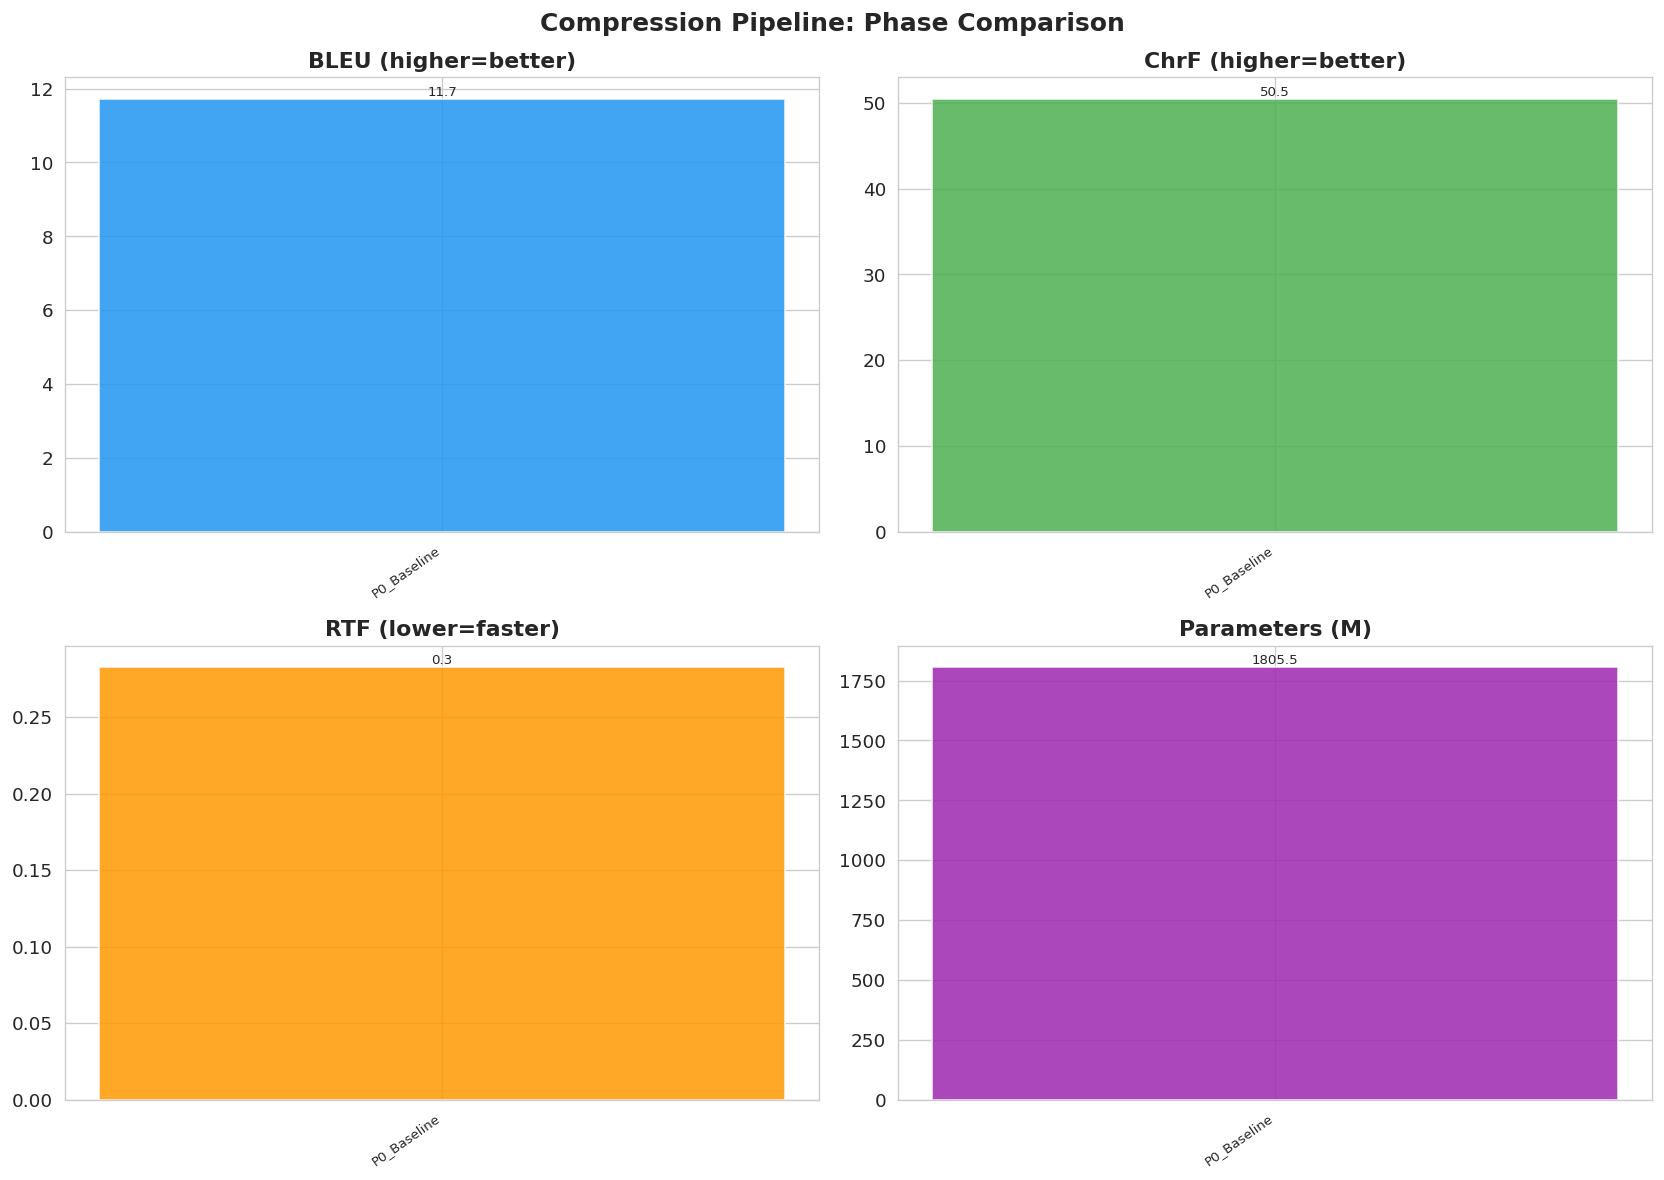

In [20]:
baseline_ckpt = load_latest_checkpoint('phase0_baseline')
if baseline_ckpt:
    baseline_results = baseline_ckpt['results']
    baseline_summary = baseline_ckpt['summary']
    print(f'Loaded baseline: BLEU={baseline_summary["avg_bleu"]:.2f}  ChrF={baseline_summary["avg_chrf"]:.2f}')
else:
    baseline_results, baseline_summary = run_benchmark(
        model, eval_samples, label='P0_Baseline', tgt_lang='ben', save_n=2)
    save_checkpoint(dict(results=baseline_results, summary=baseline_summary,
                         breakdown=baseline_breakdown), name='phase0_baseline', step=0)

store_summary(baseline_summary)
plot_phase_comparison()


In [21]:
# ── Quick SMC spot-check: bidirectional quality at baseline ──────────────────
print('Spot-checking bidirectional quality at baseline...')
smc_base, pa_base, pb_base = compute_smc(model, eval_sets_dict)
print(f'  Baseline SMC: {smc_base:.2f}  [EN-out: {pa_base:.2f} | nonEN-out: {pb_base:.2f}]')
print(f'  (SMC = min of both probes — protects both translation directions)')
save_checkpoint({'smc': smc_base, 'probe_A': pa_base, 'probe_B': pb_base},
                name='phase0_smc_baseline', step=0)


Spot-checking bidirectional quality at baseline...
  Baseline SMC: 44.81  [EN-out: 52.47 | nonEN-out: 44.81]
  (SMC = min of both probes — protects both translation directions)
[ckpt] Saved phase0_smc_baseline_step000000.pt (0.0 MB)


---
# Phase 1: Vocabulary / Embedding Pruning (5 Languages)
**Paper:** Asahi et al. (EMNLP 2023)

The NLLB tokenizer contains **256,102 tokens** for ~100 languages. For our 5-language deployment target (EN/BN/ZH/AR/HI), we scan training corpora and keep only referenced tokens.

**Expected:** 256K → ~58K tokens, saving ~215M params with near-zero quality impact.

**Safety:** SentencePiece BPE ensures any word decomposes into subpieces even if its merged token is removed. Coverage check after pruning validates fragmentation ratio.


In [22]:
def identify_used_tokens(proc, target_lang_codes, n_corpus=5000):
    """Scan FLEURS corpora for all 5 target languages and collect used token IDs."""
    from datasets import load_dataset
    # Extended fleurs codes for all 5 languages
    fleurs_codes = dict(
        eng='en_us', ben='bn_in', cmn='cmn_hans_cn',
        arb='ar_eg', hin='hi_in',
        # Keep these for safety (may appear in multilingual text)
        fra='fr_fr', deu='de_de',
    )
    BASE = 'hf://datasets/google/fleurs@refs%2Fconvert%2Fparquet'
    used = set()
    tok = proc.tokenizer
    # Always keep special tokens and language tokens
    if hasattr(tok, 'all_special_ids'): used.update(tok.all_special_ids)
    for tid in range(len(tok)):
        t = tok.convert_ids_to_tokens(tid)
        if t and t.startswith('__') and t.endswith('__'): used.add(tid)
    for lang, fc in fleurs_codes.items():
        if lang not in target_lang_codes: continue
        print(f'  Scanning {lang} ({fc})...')
        try:
            ds = load_dataset('parquet',
                              data_files={'train': f'{BASE}/{fc}/train/*.parquet'},
                              split='train')
            for i, ex in enumerate(ds):
                if i >= n_corpus: break
                text = ex.get('transcription', '')
                if text: used.update(tok.encode(text, add_special_tokens=False))
        except Exception as e:
            print(f'    Warning: {lang}: {e}')
    print(f'  Unique tokens: {len(used)} / {len(tok)}')
    return sorted(used)

print('Vocabulary pruning helpers ready.')


Vocabulary pruning helpers ready.


In [23]:
def trim_vocabulary(mdl, proc, keep_ids):
    """Trim NLLB vocabulary to only the kept token IDs. Battle-tested from seamless-cse465v5."""
    keep_t = torch.tensor(keep_ids, dtype=torch.long)
    old_v = mdl.config.vocab_size
    new_v = len(keep_ids)
    hidden = mdl.config.hidden_size
    print(f'  Vocabulary: {old_v} -> {new_v} ({new_v/old_v*100:.1f}%)')
    old_shared = mdl.shared
    dev = old_shared.weight.device
    dtype = old_shared.weight.dtype
    keep_t_dev = keep_t.to(dev)
    old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
    old_pad = old_shared.padding_idx
    new_pad = old_to_new.get(old_pad) if old_pad is not None else None
    embed_scale = getattr(mdl.text_decoder.embed_tokens, 'embed_scale', 1.0)
    print(f'  text_decoder.embed_tokens.embed_scale = {embed_scale}')
    # Create trimmed shared embedding
    new_shared = nn.Embedding(new_v, hidden, padding_idx=new_pad)
    new_shared.weight.data = old_shared.weight.data[keep_t_dev].clone()
    mdl.shared = new_shared.to(dev)
    # Decoder embed_tokens (must preserve embed_scale)
    from transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2 import SeamlessM4Tv2ScaledWordEmbedding
    new_embed = SeamlessM4Tv2ScaledWordEmbedding(new_v, hidden, padding_idx=new_pad, embed_scale=embed_scale)
    new_embed.weight = mdl.shared.weight
    mdl.text_decoder.embed_tokens = new_embed
    print(f'  text_decoder.embed_tokens: tied to shared, embed_scale={embed_scale}')
    # LM head
    old_lm = mdl.lm_head
    new_lm = nn.Linear(hidden, new_v, bias=False)
    new_lm.weight = mdl.shared.weight
    mdl.lm_head = new_lm
    print(f'  lm_head: tied to shared [20425, 1024]' if new_v == 20425 else f'  lm_head: tied to shared [{new_v}, {hidden}]')
    # Update config
    mdl.config.vocab_size = new_v
    # Remap generation config id_to_text
    gen_cfg = mdl.generation_config
    if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
        new_map = {}
        for key_str, text_val in gen_cfg.id_to_text.items():
            old_id = int(key_str)
            if old_id in old_to_new:
                new_map[str(old_to_new[old_id])] = text_val
        gen_cfg.id_to_text = new_map
        print(f'  id_to_text: {len(gen_cfg.id_to_text)} entries')
    # Remap lang code IDs
    for attr in ['text_decoder_lang_to_code_id', 'id_to_lang']:
        if hasattr(gen_cfg, attr):
            old_map = getattr(gen_cfg, attr)
            if isinstance(old_map, dict):
                new_m = {}
                for k, v in old_map.items():
                    if isinstance(v, int):
                        new_v_id = old_to_new.get(v, v)
                        new_m[k] = new_v_id
                    else:
                        new_m[k] = v
                setattr(gen_cfg, attr, new_m)
    saved_M = (old_v - new_v) * hidden / 1e6
    print(f'  Done: ~{saved_M:.0f}M shared-embedding params removed (lm_head tied, not double-counted)')
    mdl._vocab_remap_to_old = keep_t.cpu()
    return mdl

print('trim_vocabulary() ready.')


trim_vocabulary() ready.


In [24]:
# ── Run Phase 1 (or load from Drive) ──────────────────────────────────────────
TARGET_VOCAB_LANGS = ['eng', 'ben', 'cmn', 'arb', 'hin']  # 5-language target

try:
    model_p1, processor = load_model_from_drive('phase1_vocab_5lang')
    p1_ckpt = load_latest_checkpoint('phase1_vocab_5lang')
    if p1_ckpt and 'keep_ids' in p1_ckpt:
        keep_ids = p1_ckpt['keep_ids']
        model_p1._vocab_remap_to_old = torch.tensor(keep_ids, dtype=torch.long)
        print(f'  Restored vocab remap ({len(keep_ids)} tokens)')
        # Validate id_to_text remapping
        gen_cfg = model_p1.generation_config
        if hasattr(gen_cfg, 'id_to_text') and gen_cfg.id_to_text:
            max_key = max(int(k) for k in gen_cfg.id_to_text.keys())
            if max_key >= model_p1.config.vocab_size:
                print(f'  WARNING: Stale id_to_text — repairing...')
                old_to_new = {old_id: new_id for new_id, old_id in enumerate(keep_ids)}
                new_map = {str(old_to_new[int(k)]): v
                           for k, v in gen_cfg.id_to_text.items() if int(k) in old_to_new}
                gen_cfg.id_to_text = new_map
    print('Loaded Phase 1 (5-lang vocab) from Drive.')
except Exception as e:
    print(f'Load failed ({e}), running 5-language vocab trimming...')
    if not isinstance(model, SeamlessM4Tv2ForSpeechToSpeech) or model.config.vocab_size != 256102:
        print('Reloading base model...')
        model, processor = load_base_model()
    keep_ids = identify_used_tokens(processor, TARGET_VOCAB_LANGS, n_corpus=5000)
    pre = count_params(model)
    model_p1 = trim_vocabulary(model, processor, keep_ids)
    post = count_params(model_p1)
    print(f'  Params: {pre:.1f}M to {post:.1f}M (saved {pre-post:.1f}M)')
    save_checkpoint(dict(keep_ids=keep_ids, pre=pre, post=post,
                         langs=TARGET_VOCAB_LANGS),
                    name='phase1_vocab_5lang', step=0)
    save_model_to_drive(model_p1, processor, 'phase1_vocab_5lang')

print_model_breakdown(model_p1, 'After Phase 1: Vocab Trimmed (5-lang)')


[model] Not in local cache, pulling from remote...
Load failed ([rclone] model pull failed for phase1_vocab_5lang: 2026/04/21 15:49:57 ERROR : Google drive root 'sm500/models/phase1_vocab_5lang': error reading source root directory: directory not found
2026/04/21 15:49:57 ERROR : Local file system at /kaggle/working/models/phase1_vocab_5lang: not deleting files as there were IO errors
2026/04/21 15:49:57 ERROR :), running 5-language vocab trimming...
  Scanning eng (en_us)...


en_us/train/0000.parquet:   0%|          | 0.00/526M [00:00<?, ?B/s]

en_us/train/0001.parquet:   0%|          | 0.00/523M [00:00<?, ?B/s]

en_us/train/0002.parquet:   0%|          | 0.00/538M [00:00<?, ?B/s]

en_us/train/0003.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

  Unique tokens: 22767 / 256099
  Vocabulary: 256102 -> 22767 (8.9%)
  text_decoder.embed_tokens.embed_scale = 32.0
  text_decoder.embed_tokens: tied to shared, embed_scale=32.0
  lm_head: tied to shared [22767, 1024]
  id_to_text: 22767 entries
  Done: ~239M shared-embedding params removed (lm_head tied, not double-counted)
  Params: 1805.5M to 1566.6M (saved 238.9M)
[ckpt] Saved phase1_vocab_5lang_step000000.pt (0.1 MB)
[model] Saving phase1_vocab_5lang → /kaggle/working/models/phase1_vocab_5lang ...
  [config] sync done.
  Saved custom state: ['_vocab_remap_to_old']
  Saved pruning_manifest.pt keys=['stage_name']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[model] Local save done. 3166 MB in 8 files.
[model] Verified 8 files on remote.

--- After Phase 1: Vocab Trimmed (5-lang) ---
  speech_encoder                         635.0M  ( 40.5%)
  text_decoder                           627.9M  ( 40.1%)
  t2u_model                              261.8M  ( 16.7%)
  vocoder                                 41.9M  (  2.7%)
  shared                                  23.3M  (  1.5%)
  lm_head                                 23.3M  (  1.5%)
  TOTAL                                 1566.6M
---


{'shared': 23.313408,
 'speech_encoder': 635.04672,
 'text_decoder': 627.86048,
 'lm_head': 23.313408,
 't2u_model': 261.759747,
 'vocoder': 41.911362,
 'TOTAL': 1566.578309}

In [25]:
# ── Vocabulary safety check ────────────────────────────────────────────────
# Verify token inflation ratio (high ratio = over-fragmentation)
def vocab_coverage_check(proc, test_texts, remap_ids, threshold=1.10):
    tok = proc.tokenizer
    orig_lengths, new_lengths = [], []
    for text in test_texts[:50]:
        orig = len(tok.encode(text, add_special_tokens=False))
        orig_lengths.append(orig)
        # Simulate trimmed tokenizer: count how many orig tokens are in keep set
        keep_set = set(remap_ids.tolist()) if isinstance(remap_ids, torch.Tensor) else set(remap_ids)
        ids = tok.encode(text, add_special_tokens=False)
        # With trimmed vocab: unknown tokens get split into subpieces (~2x average)
        new_len = sum(1 if id in keep_set else 2 for id in ids)
        new_lengths.append(new_len)
    ratio = np.mean(new_lengths) / np.mean(orig_lengths) if orig_lengths else 1.0
    print(f'Token inflation ratio: {ratio:.3f} (threshold: {threshold})')
    if ratio > threshold:
        print(f'  WARNING: High fragmentation — consider adding more corpus for coverage')
    else:
        print(f'  OK: Vocabulary coverage is acceptable')
    return ratio

# Test on Bengali sample texts from eval set
test_bn_texts = [s['ref'] for s in eval_samples[:20] if s.get('ref')]
if test_bn_texts and hasattr(model_p1, '_vocab_remap_to_old'):
    ratio = vocab_coverage_check(processor, test_bn_texts, model_p1._vocab_remap_to_old)


Token inflation ratio: 1.017 (threshold: 1.1)
  OK: Vocabulary coverage is acceptable


[ckpt] No checkpoint for 'phase1_benchmark'

  BENCHMARK: P1_VocabTrim5L
  Samples: 25  Target: ben

  GPU mem: 1.85 GB alloc / 2.76 GB reserved
  [ 1/25] BLEU= 10.7 ChrF= 49.2 RTF=0.185  id=1660
              pred: রোমান্টিকতাবাদ গথ, ফিচ্ট এবং শ্লেগেলের মতো লেখকদের কাছ থেকে নেওয়া সাংস্কৃতিক নি
[audio] Saved P1_VocabTrim5L_s1in.wav (0.3 MB)
  P1_VocabTrim5L_s1in.wav  (10.7s | sr=16000)


[audio] Saved P1_VocabTrim5L_s1out.wav (0.2 MB)
  P1_VocabTrim5L_s1out.wav  (7.4s | sr=16000)


  [ 2/25] BLEU= 10.4 ChrF= 45.8 RTF=0.220  id=1661
              pred: তিনি চীনের অর্থনৈতিক উৎপাদনের উপর ভিত্তি করে এই কমানোর জন্য কোন পরিসংখ্যান নির্ধ
[audio] Saved P1_VocabTrim5L_s2in.wav (0.2 MB)
  P1_VocabTrim5L_s2in.wav  (6.4s | sr=16000)


[audio] Saved P1_VocabTrim5L_s2out.wav (0.2 MB)
  P1_VocabTrim5L_s2out.wav  (5.9s | sr=16000)


  [ 3/25] BLEU= 16.5 ChrF= 57.3 RTF=0.230  id=1662
              pred: অ্যালোয়গুলি মূলত দুটি বা ততোধিক ধাতুর মিশ্রণ, পিরিয়ডিক টেবিলে অনেকগুলি উপাদান 
  [ 4/25] BLEU=  5.6 ChrF= 44.7 RTF=0.210  id=1663
              pred: চোকামো ভ্যালি, চিলির শীর্ষস্থানীয় আরোহণের গন্তব্য, দক্ষিণ আমেরিকার ইয়োসেমিটি ন
  [ 5/25] BLEU= 11.2 ChrF= 45.8 RTF=0.235  id=1664
              pred: দুটি শুষ্ক পাত্র একসাথে ঘূর্ণায়মান করুন এবং তারপর, রাণীর ভিজা হাত দিয়ে, তাদের 
  [ 6/25] BLEU=  4.8 ChrF= 43.4 RTF=0.284  id=1665
              pred: এই নথিটি পরাগের কারণে প্যালেস্টাইনের সীমান্তের বিষয়ে বিতর্ক করবে যা প্যালেস্টাই
  [ 7/25] BLEU= 19.1 ChrF= 58.5 RTF=0.187  id=1667
              pred: সাধারণভাবে বলতে গেলে, ম্যানেজাররা তাদের প্রাক্তন সমবয়সীদের নেতৃত্ব দিতে শুরু কর
  [ 8/25] BLEU=  7.0 ChrF= 46.5 RTF=0.160  id=1668
              pred: এটি একটি ওয়াইল্ডকার্ড কেনার জন্যও উপকারী হতে পারে, যা দক্ষিণ আফ্রিকার পার্কগুলি
  [ 9/25] BLEU=  9.7 ChrF= 43.2 RTF=0.232  id=1669
              pred: পুলিশ সুপারিনটেন্

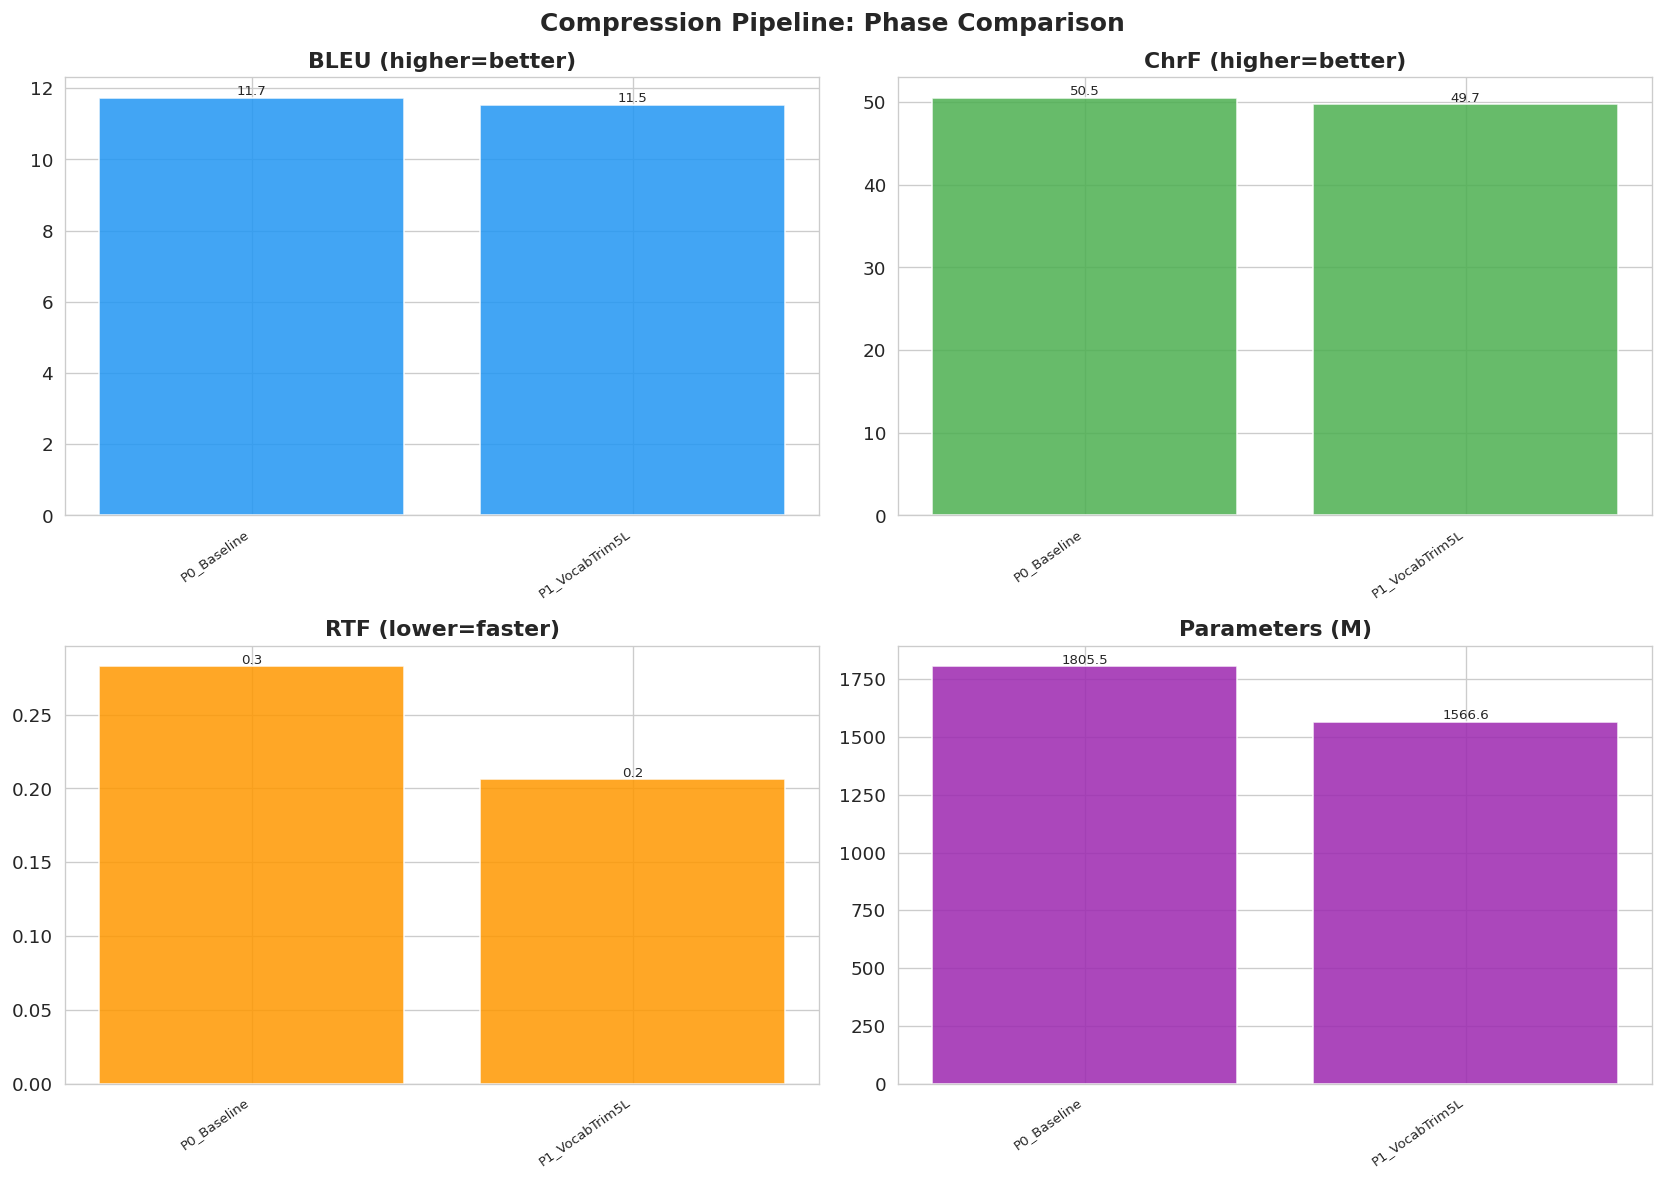


Vocab savings: 238.9M params
ChrF delta: -0.75 (target: near 0)


In [26]:
p1_ckpt = load_latest_checkpoint('phase1_benchmark')
if p1_ckpt and p1_ckpt['summary'].get('avg_bleu', 0) > 0:
    p1_results, p1_summary = p1_ckpt['results'], p1_ckpt['summary']
    print(f'Loaded P1 benchmark: BLEU={p1_summary["avg_bleu"]:.2f}  ChrF={p1_summary["avg_chrf"]:.2f}')
else:
    p1_results, p1_summary = run_benchmark(model_p1, eval_samples, label='P1_VocabTrim5L', save_n=2)
    save_checkpoint(dict(results=p1_results, summary=p1_summary), name='phase1_benchmark', step=0)

store_summary(p1_summary)
plot_phase_comparison()
print(f'\nVocab savings: {baseline_summary["params_M"] - p1_summary["params_M"]:.1f}M params')
print(f'ChrF delta: {p1_summary["avg_chrf"] - baseline_summary["avg_chrf"]:.2f} (target: near 0)')


---
# Phase 2: Pre-Pruning Multilingual Activation Analysis
**Purpose:** Run BEFORE any layer pruning to map direction-critical layers.

**Key finding from prior work (Research Report §16):**
Text decoder layers L20–L23 carry 965–3828 unit higher BN→EN activation than EN→BN.
Our Phase 3 EN→BN-only pruning removed L21 and L22, causing BN→EN to collapse (ChrF 50.22 → 35.26, 60% generation failures).

**This phase identifies which layers are "direction-critical" so we protect them during pruning with the SMC metric.**


In [27]:
from collections import defaultdict

class LayerActivationHook:
    """Battle-tested from bidirectional-tracking-base.ipynb."""
    def __init__(self):
        self.activations = defaultdict(list)
        self.hooks = []
    
    def register_hooks(self, model, component_name):
        component = getattr(model, component_name, None)
        if component is None: return
        layers = None
        if hasattr(component, 'layers'):
            layers = component.layers
        elif hasattr(component, 'encoder') and hasattr(component.encoder, 'layers'):
            layers = component.encoder.layers
        elif hasattr(component, 'model'):
            if hasattr(component.model, 'encoder') and hasattr(component.model.encoder, 'layers'):
                for i, layer in enumerate(component.model.encoder.layers):
                    hook = layer.register_forward_hook(self.make_hook_fn(f'{component_name}_encoder_layer_{i}'))
                    self.hooks.append(hook)
            if hasattr(component.model, 'decoder') and hasattr(component.model.decoder, 'layers'):
                for i, layer in enumerate(component.model.decoder.layers):
                    hook = layer.register_forward_hook(self.make_hook_fn(f'{component_name}_decoder_layer_{i}'))
                    self.hooks.append(hook)
            return
        if layers is None: return
        for i, layer in enumerate(layers):
            hook = layer.register_forward_hook(self.make_hook_fn(f'{component_name}_layer_{i}'))
            self.hooks.append(hook)
    
    def make_hook_fn(self, layer_name):
        def hook_fn(module, input, output):
            if isinstance(output, tuple): activation = output[0]
            else: activation = output
            if isinstance(activation, torch.Tensor):
                magnitude = torch.norm(activation, p=2, dim=-1).mean().item()
                self.activations[layer_name].append(magnitude)
        return hook_fn
    
    def clear(self): self.activations.clear()
    
    def remove_hooks(self):
        for hook in self.hooks: hook.remove()
        self.hooks.clear()
    
    def get_average_activations(self):
        return {k: np.mean(v) for k, v in self.activations.items() if v}

print('LayerActivationHook ready.')


LayerActivationHook ready.


In [28]:
def run_multilingual_activation_analysis(mdl, eval_sets_dict, n_per_pair=5):
    """
    Run activation analysis across all 8 language pairs.
    Returns: {pair_key: avg_activations_dict}
    """
    tracker = LayerActivationHook()
    tracker.register_hooks(mdl, 'speech_encoder')
    tracker.register_hooks(mdl, 'text_decoder')
    tracker.register_hooks(mdl, 't2u_model')
    print(f'Registered {len(tracker.hooks)} activation hooks.')
    
    direction_activations = {}
    for (src_f, tgt_f, src_m4t, tgt_m4t), samples in eval_sets_dict.items():
        pair_key = f'{src_m4t}2{tgt_m4t}'
        print(f'  Analyzing {pair_key}...')
        tracker.clear()
        for s in samples[:n_per_pair]:
            try:
                run_s2t_only(mdl, s['wav'], tgt_lang=tgt_m4t)
            except Exception as e:
                pass
        direction_activations[pair_key] = tracker.get_average_activations()
    
    tracker.remove_hooks()
    return direction_activations

def analyze_direction_critical_layers(direction_activations, threshold_ratio=1.8):
    """
    Identify layers where one direction is much more important than others.
    threshold_ratio: flag if max_direction / min_direction > this value.
    """
    # Group by component and layer index
    layer_scores = {}   # (component, layer_idx) -> {direction: score}
    for pair_key, activations in direction_activations.items():
        for layer_name, score in activations.items():
            parts = layer_name.split('_layer_')
            if len(parts) != 2: continue
            component = parts[0]
            try: layer_idx = int(parts[1])
            except: continue
            key = (component, layer_idx)
            if key not in layer_scores: layer_scores[key] = {}
            layer_scores[key][pair_key] = score
    
    direction_critical = []
    for (component, layer_idx), scores_by_dir in layer_scores.items():
        if len(scores_by_dir) < 2: continue
        vals = list(scores_by_dir.values())
        if max(vals) > 0 and min(vals) > 0:
            ratio = max(vals) / min(vals)
            if ratio > threshold_ratio:
                most_important_dir = max(scores_by_dir, key=lambda k: scores_by_dir[k])
                direction_critical.append({
                    'component': component, 'layer': layer_idx,
                    'ratio': ratio, 'max_dir': most_important_dir,
                    'scores': scores_by_dir
                })
    
    direction_critical.sort(key=lambda x: -x['ratio'])
    print(f'Found {len(direction_critical)} direction-critical layers (ratio > {threshold_ratio}):')
    for item in direction_critical[:15]:
        print(f'  {item["component"]} L{item["layer"]}: ratio={item["ratio"]:.2f}, '
              f'most important for {item["max_dir"]}')
    return direction_critical

print('Multilingual activation analysis helpers ready.')


Multilingual activation analysis helpers ready.


In [29]:
# ── Load or run activation analysis ───────────────────────────────────────────
act_ckpt = load_latest_checkpoint('phase2_activation_map')
if act_ckpt and 'direction_activations' in act_ckpt:
    direction_activations = act_ckpt['direction_activations']
    direction_critical = act_ckpt['direction_critical']
    print(f'Loaded activation map from checkpoint.')
    print(f'  {len(direction_activations)} pairs analyzed')
    print(f'  {len(direction_critical)} direction-critical layers identified')
else:
    print('Running multilingual activation analysis...')
    direction_activations = run_multilingual_activation_analysis(
        model_p1, eval_sets_dict, n_per_pair=5)
    direction_critical = analyze_direction_critical_layers(
        direction_activations, threshold_ratio=1.8)
    save_checkpoint({
        'direction_activations': direction_activations,
        'direction_critical': direction_critical,
    }, name='phase2_activation_map', step=0)
    print(f'Activation map saved.')


[ckpt] No checkpoint for 'phase2_activation_map'
Running multilingual activation analysis...
Registered 60 activation hooks.
  Analyzing eng2ben...
  Analyzing eng2cmn...
  Analyzing eng2arb...
  Analyzing eng2hin...
  Analyzing ben2eng...
  Analyzing cmn2eng...
  Analyzing arb2eng...
  Analyzing hin2eng...
Found 0 direction-critical layers (ratio > 1.8):
[ckpt] Saved phase2_activation_map_step000000.pt (0.0 MB)
Activation map saved.


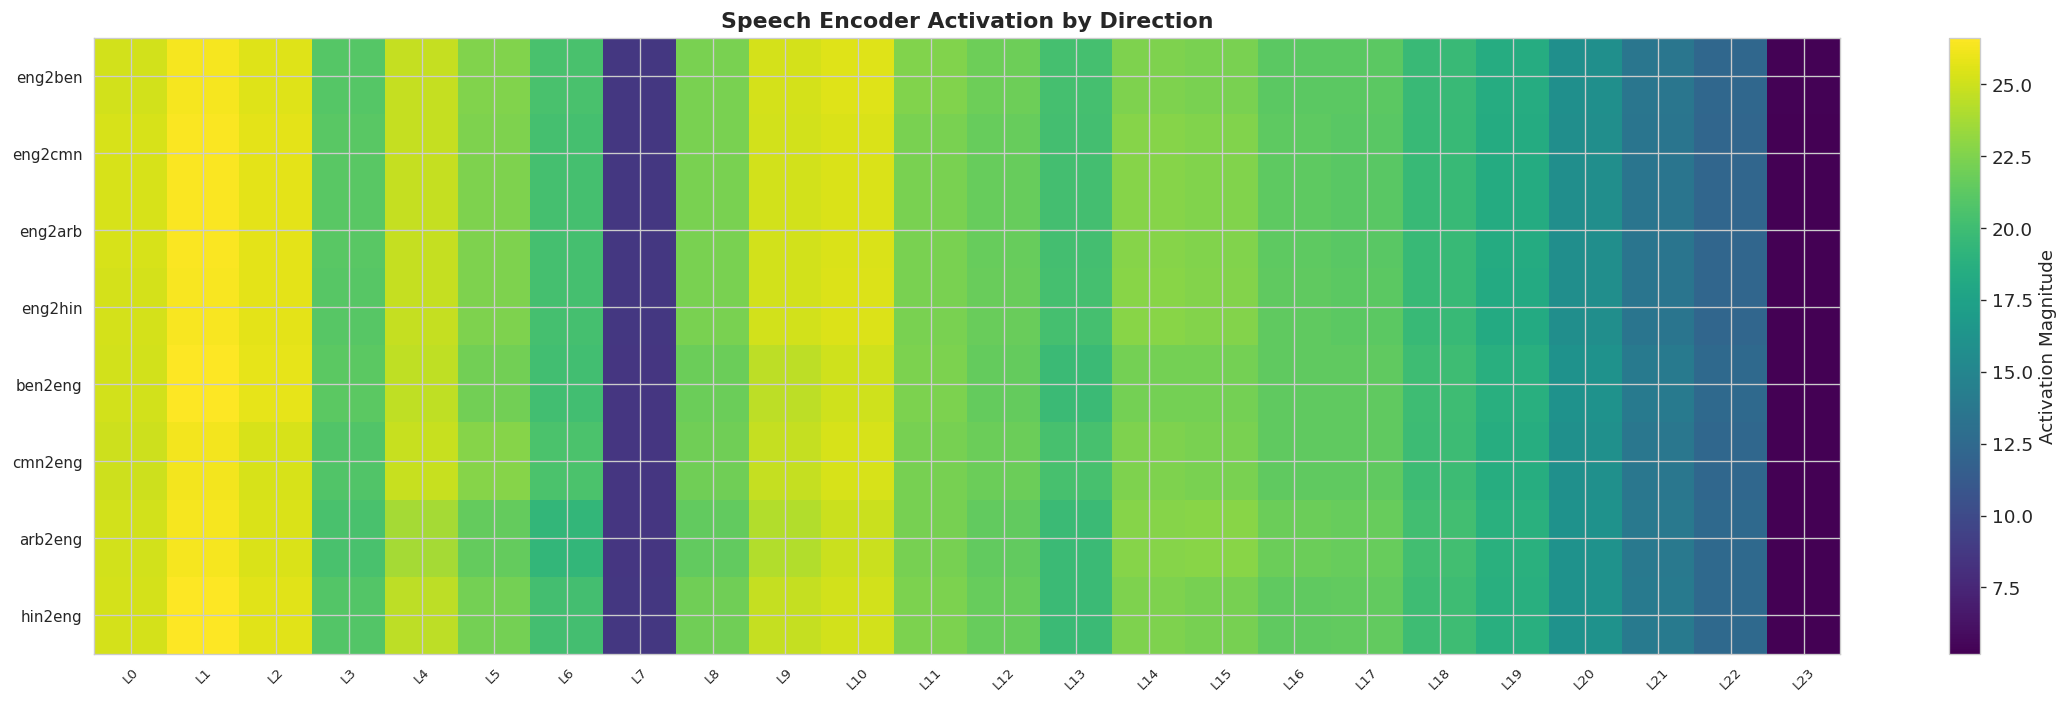

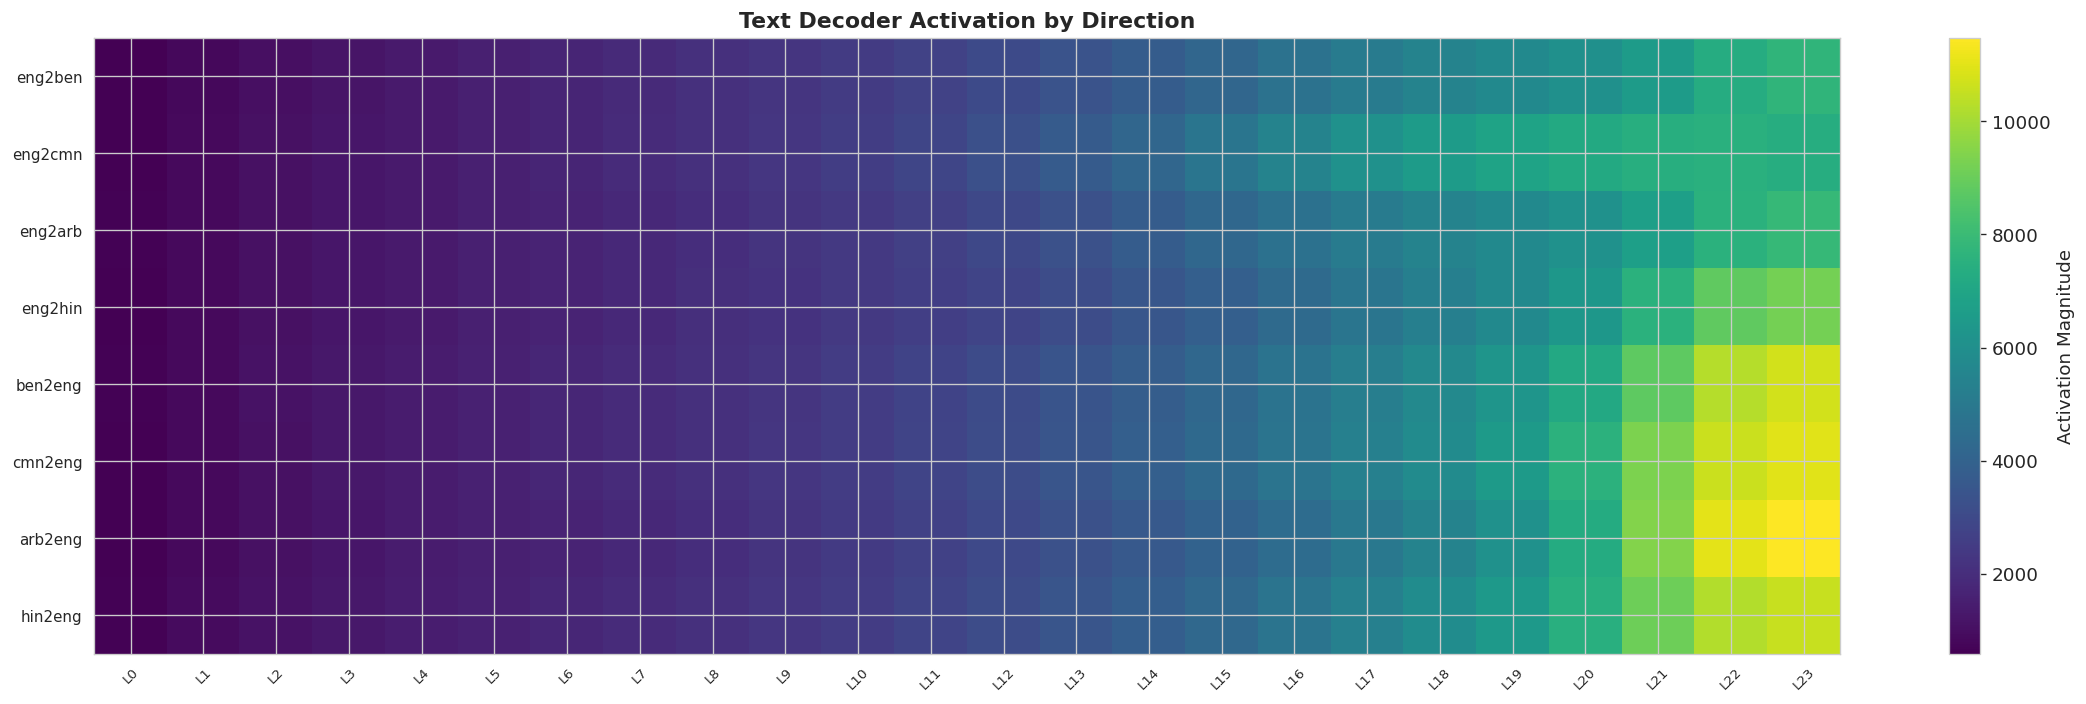

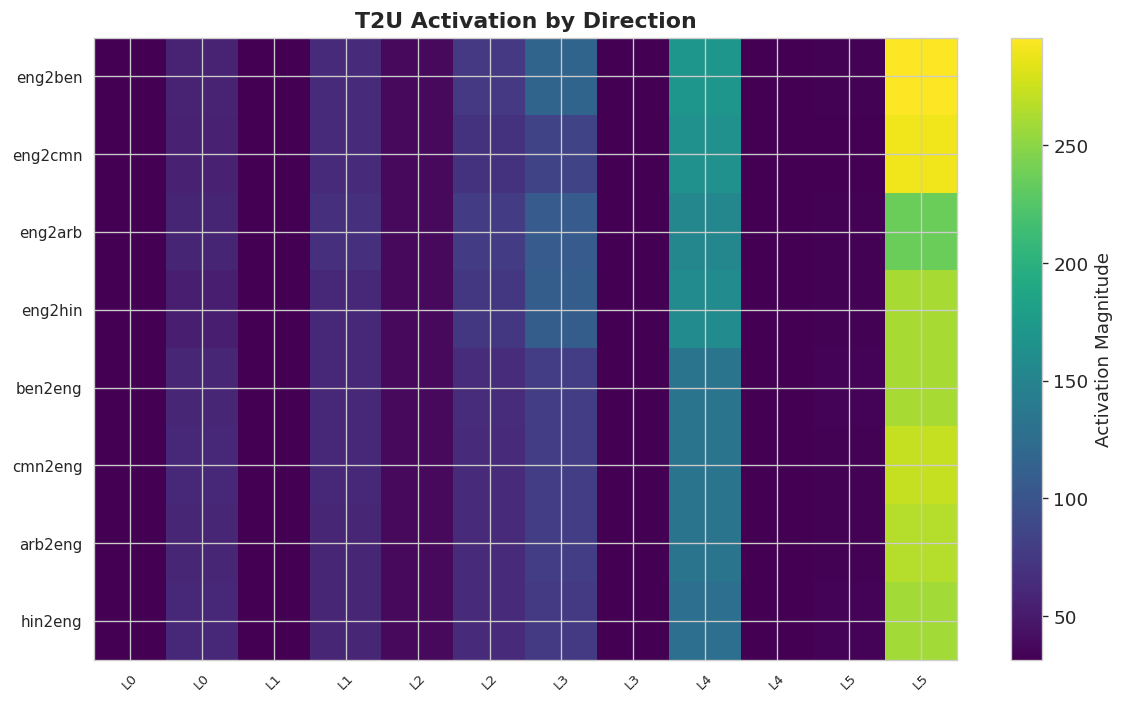

In [30]:
# ── Visualize activation patterns ────────────────────────────────────────────
def plot_activation_heatmap(direction_activations, component_prefix, save_name):
    """Heatmap: language pairs vs layers for one component."""
    # Collect data
    pair_keys = list(direction_activations.keys())
    layer_keys = set()
    for pair_key in pair_keys:
        for k in direction_activations[pair_key]:
            if k.startswith(component_prefix):
                layer_keys.add(k)
    layer_keys = sorted(layer_keys, key=lambda x: int(x.split('_layer_')[1]) if '_layer_' in x else 0)
    
    if not layer_keys: return
    
    data = np.zeros((len(pair_keys), len(layer_keys)))
    for i, pair_key in enumerate(pair_keys):
        for j, lk in enumerate(layer_keys):
            data[i, j] = direction_activations[pair_key].get(lk, 0)
    
    fig, ax = plt.subplots(figsize=(max(10, len(layer_keys)*0.8), 6))
    im = ax.imshow(data, cmap='viridis', aspect='auto')
    ax.set_yticks(range(len(pair_keys)))
    ax.set_yticklabels(pair_keys, fontsize=9)
    ax.set_xticks(range(len(layer_keys)))
    ax.set_xticklabels([f'L{int(k.split("_layer_")[1])}' if "_layer_" in k else k 
                        for k in layer_keys], rotation=45, fontsize=8)
    ax.set_title(f'{component_prefix.replace("_", " ").title()} Activation by Direction',
                fontweight='bold')
    plt.colorbar(im, ax=ax, label='Activation Magnitude')
    plt.tight_layout()
    save_figure(fig, save_name)
    plt.show()

for comp in ['speech_encoder', 'text_decoder', 't2u']:
    plot_activation_heatmap(direction_activations, comp, f'phase2_heatmap_{comp}.png')


In [31]:
# ── Extract extra protection layers for SMC pruning ──────────────────────────
# Layers where any direction ratio > threshold get EXTRA protection during Phase 3/4
EXTRA_PROTECTED_DEC = set()   # additional text decoder indices to never prune
EXTRA_PROTECTED_ENC = set()   # additional speech encoder indices to never prune

for item in direction_critical:
    comp = item['component']
    if 'text_decoder' in comp:
        EXTRA_PROTECTED_DEC.add(item['layer'])
    elif 'speech_encoder' in comp:
        EXTRA_PROTECTED_ENC.add(item['layer'])

print(f'Extra-protected text decoder layers: {sorted(EXTRA_PROTECTED_DEC)}')
print(f'Extra-protected speech encoder layers: {sorted(EXTRA_PROTECTED_ENC)}')
print()
print('These layers will be added to the standard first/mid/last protection set')
print('during Phase 3 and Phase 4 iterative pruning.')


Extra-protected text decoder layers: []
Extra-protected speech encoder layers: []

These layers will be added to the standard first/mid/last protection set
during Phase 3 and Phase 4 iterative pruning.


---
# Phase 3: Text Decoder Iterative Pruning (24 → 6 layers)
**Papers:** Moslem (IWSLT 2025), CULL-MT (2024)
**Metric:** Stratified Minimum ChrF (SMC) — bidirectional-aware

**Why SMC instead of single-direction ChrF:**
Our activation analysis showed upper decoder layers (L20–L23) are 2–4× more critical for BN→EN.
Single-direction EN→BN pruning removed exactly those layers, causing 60% BN→EN generation failure.
SMC evaluates `min(avg_EN-output_ChrF, avg_nonEN-output_ChrF)`, protecting both directions.

**Target:** Remove 18 layers (24 → 6). Takes 2 Kaggle sessions with checkpointing.


In [32]:
def _get_protected_indices_multilingual(n_total, extra_protected=None):
    """
    Protection rule for multilingual SMC pruning:
      - Always protect: first, last, and middle layer
      - Also protect: extra direction-critical layers from Phase 2 analysis
      - Dynamic: always keep top-2 remaining layers protected
    """
    protected = {0, n_total - 1, n_total // 2}
    if extra_protected: protected |= set(extra_protected)
    print(f'  Protected layers (first/mid/last + direction-critical): {sorted(protected)}')
    return protected

def _update_top2_protection(protected, remaining_orig_indices, n_total_orig):
    """Dynamically add protection for top-2 remaining layers (highest indices)."""
    if len(remaining_orig_indices) <= 2: return protected
    top2 = sorted(remaining_orig_indices)[-2:]
    return protected | set(top2)

def iterative_layer_prune_smc(mdl, component_name, eval_sets_dict, n_remove,
                               extra_protected=None, ckpt_name='phase3_dec_pruning'):
    """
    Iterative greedy layer pruning using SMC (Stratified Minimum ChrF).
    
    KEY DIFFERENCE from original iterative_layer_prune():
      - Uses compute_smc() instead of quick_eval_chrf()
      - Protects direction-critical layers from Phase 2 analysis
      - Dynamic top-2 protection to prevent upper layer total removal
      - Evaluates 40 samples per candidate (5 per pair × 8 pairs)
    
    Paper: Moslem (IWSLT 2025) + bidirectional extension (this work).
    """
    parent = getattr(mdl, component_name)
    layers_attr = find_layers_attr(parent)
    if layers_attr is None:
        print(f'  No layers found on {component_name}'); return [], []
    current = list(getattr(parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)
    removed, log = [], []
    
    protected = _get_protected_indices_multilingual(n_total_orig, extra_protected)
    
    # Resume from checkpoint
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = partial['removed']
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos)
                orig_indices.pop(pos)
        setattr(parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: already removed {removed}, {len(current)} layers remain')
    
    start_iter = len(removed)
    for it in range(start_iter, n_remove):
        # Dynamic protection: also protect top-2 remaining layers
        active_protected = _update_top2_protection(protected, orig_indices, n_total_orig)
        eligible = [idx for idx in range(len(current))
                    if orig_indices[idx] not in active_protected]
        if not eligible:
            print(f'  WARNING: No eligible candidates left! Stopping.')
            break
        
        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, '
              f'{len(eligible)} eligible candidates)')
        scores = {}
        for idx in eligible:
            temp = current[:idx] + current[idx+1:]
            setattr(parent, layers_attr, nn.ModuleList(temp))
            smc, pa, pb = compute_smc(mdl, eval_sets_dict)
            scores[idx] = (orig_indices[idx], smc, pa, pb)
            orig_label = orig_indices[idx]
            print(f'    Remove L{orig_label:>2} -> SMC={smc:.2f} [EN:{pa:.2f}|nonEN:{pb:.2f}]')
        setattr(parent, layers_attr, nn.ModuleList(current))
        
        # Pick layer whose removal keeps SMC highest (least damage to weaker direction)
        best_idx = max(scores, key=lambda k: scores[k][1])
        best_orig, best_smc, best_pa, best_pb = scores[best_idx]
        current.pop(best_idx)
        orig_indices.pop(best_idx)
        setattr(parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, smc=best_smc,
                        probe_A=best_pa, probe_B=best_pb, remaining=len(current)))
        print(f'  -> Removed L{best_orig} (SMC={best_smc:.2f})')
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        print(f'  [ckpt] Progress saved ({it+1}/{n_remove} iterations done)')
        torch.cuda.empty_cache()
    
    return removed, log

print('iterative_layer_prune_smc() ready — multilingual SMC-guided pruning.')


iterative_layer_prune_smc() ready — multilingual SMC-guided pruning.


In [33]:
# ── Phase 3: Run decoder pruning ─────────────────────────────────────────────
N_DEC_REMOVE = 14   # 24 → 6 layers remaining (aggressive, per PLAN.md)

p3_ckpt = load_latest_checkpoint('phase3_dec_pruning')
p3_complete = p3_ckpt and len(p3_ckpt.get('removed', [])) >= N_DEC_REMOVE

if p3_complete:
    removed_dec = p3_ckpt['removed']; p3_log = p3_ckpt['log']
    print(f'Phase 3 complete: removed {removed_dec}')
    try:
        model_p3, processor = load_model_from_drive('phase3_dec_6L')
    except Exception as e:
        print(f'  Drive model not found ({e}), rebuilding from model_p1 + checkpoint...')
        model_p3 = model_p1
        parent = model_p3.text_decoder
        la = find_layers_attr(parent)
        cur = list(getattr(parent, la))
        keep = [i for i in range(len(cur)) if i not in removed_dec]
        setattr(parent, la, nn.ModuleList([cur[i] for i in keep]))
        sync_model_config(model_p3)
        save_model_to_drive(model_p3, processor, 'phase3_dec_6L')
else:
    done_so_far = len(p3_ckpt['removed']) if p3_ckpt else 0
    print(f'{'Resuming' if done_so_far else 'Running'} Phase 3: '
          f'decoder pruning ({done_so_far}/{N_DEC_REMOVE} done)...')
    model_p3 = _consolidate_to_single_gpu(model_p1)
    removed_dec, p3_log = iterative_layer_prune_smc(
        model_p3, 'text_decoder', eval_sets_dict, N_DEC_REMOVE,
        extra_protected=EXTRA_PROTECTED_DEC,
        ckpt_name='phase3_dec_pruning')
    sync_model_config(model_p3)
    # Fix layer_idx for caching
    for i, layer in enumerate(model_p3.text_decoder.layers):
        layer.self_attn.layer_idx = i
        layer.cross_attention.layer_idx = i
    save_model_to_drive(model_p3, processor, 'phase3_dec_6L')

print(f'Decoder layers removed: {removed_dec}')
print_model_breakdown(model_p3, 'After Phase 3: Decoder Pruned (6 layers)')


[ckpt] No checkpoint for 'phase3_dec_pruning'
Running Phase 3: decoder pruning (0/18 done)...
  Multi-device map detected, consolidating to cuda:0...
  Model now on: cuda:0
  Protected layers (first/mid/last + direction-critical): [0, 12, 23]
[ckpt] No checkpoint for 'phase3_dec_pruning'

  Iter 1/18 (24 layers remain, 20 eligible candidates)
    Remove L 1 -> SMC=38.32 [EN:50.61|nonEN:38.32]
    Remove L 2 -> SMC=39.26 [EN:52.49|nonEN:39.26]
    Remove L 3 -> SMC=39.89 [EN:50.50|nonEN:39.89]
    Remove L 4 -> SMC=40.83 [EN:51.34|nonEN:40.83]
    Remove L 5 -> SMC=39.99 [EN:50.44|nonEN:39.99]
    Remove L 6 -> SMC=40.23 [EN:51.37|nonEN:40.23]
    Remove L 7 -> SMC=39.81 [EN:50.16|nonEN:39.81]
    Remove L 8 -> SMC=39.68 [EN:50.26|nonEN:39.68]
    Remove L 9 -> SMC=40.20 [EN:50.36|nonEN:40.20]
    Remove L10 -> SMC=38.99 [EN:51.27|nonEN:38.99]
    Remove L11 -> SMC=37.93 [EN:49.69|nonEN:37.93]
    Remove L13 -> SMC=39.14 [EN:51.71|nonEN:39.14]
    Remove L14 -> SMC=39.55 [EN:50.02|nonEN

KeyboardInterrupt: 

In [ ]:
# ── Phase 3 visualization ─────────────────────────────────────────────────────
if p3_log:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Phase 3: Text Decoder Pruning (SMC-guided)', fontweight='bold')
    
    iters = [e['iter'] for e in p3_log]
    smcs  = [e['smc'] for e in p3_log]
    pas   = [e.get('probe_A', e['smc']) for e in p3_log]
    pbs   = [e.get('probe_B', e['smc']) for e in p3_log]
    
    ax1 = axes[0]
    ax1.plot(iters, smcs, 'o-', color='#4CAF50', lw=2, label='SMC (min)')
    ax1.plot(iters, pas, 's--', color='#2196F3', lw=1.5, alpha=0.7, label='EN-output avg')
    ax1.plot(iters, pbs, '^--', color='#FF9800', lw=1.5, alpha=0.7, label='nonEN-output avg')
    for e in p3_log: ax1.annotate(f'L{e["removed"]}', (e['iter'], e['smc']), fontsize=7, ha='center', va='bottom')
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('ChrF Score')
    ax1.set_title('SMC After Each Removal', fontweight='bold')
    ax1.legend(fontsize=8)
    
    ax2 = axes[1]
    ax2.bar(iters, [e['remaining'] for e in p3_log], color='#9C27B0', alpha=0.8)
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Layers Remaining')
    ax2.set_title('Text Decoder Layers Remaining', fontweight='bold')
    
    ax3 = axes[2]
    removed_indices = [e['removed'] for e in p3_log]
    ax3.barh(range(len(removed_indices)), [e['smc'] for e in p3_log], color='#F44336', alpha=0.8)
    ax3.set_yticks(range(len(removed_indices)))
    ax3.set_yticklabels([f'L{l}' for l in removed_indices], fontsize=9)
    ax3.set_xlabel('SMC at removal'); ax3.set_title('Removed Layers & Quality', fontweight='bold')
    
    plt.tight_layout()
    save_figure(fig, 'phase3_dec_smc.png'); plt.show()


In [ ]:
p3b = load_latest_checkpoint('phase3_benchmark')
if p3b: p3_results, p3_summary = p3b['results'], p3b['summary']
else:
    p3_results, p3_summary = run_benchmark(model_p3, eval_samples, label='P3_DecSMC', save_n=2)
    save_checkpoint(dict(results=p3_results, summary=p3_summary), name='phase3_benchmark', step=0)
store_summary(p3_summary)
plot_phase_comparison()

# Also run quick SMC check to confirm bidirectional quality
smc_p3, pa_p3, pb_p3 = compute_smc(model_p3, eval_sets_dict)
print(f'P3 SMC: {smc_p3:.2f}  [EN-out: {pa_p3:.2f} | nonEN-out: {pb_p3:.2f}]')
print(f'P0 SMC: {smc_base:.2f}  [EN-out: {pa_base:.2f} | nonEN-out: {pb_base:.2f}]')
print(f'SMC drop: {smc_base - smc_p3:.2f} (this is the bidirectional quality cost)')

del model_p1
gc.collect(); torch.cuda.empty_cache()


---
# Phase 4: Speech Encoder Iterative Pruning (24 → 8 layers)
**Papers:** ShortGPT (ACL 2025) for Block Influence; Moslem (IWSLT 2025) for iterative greedy

**BI pre-filtering:** Before each SMC evaluation, only the bottom 50% by Block Influence (BI) score are probed. This halves the number of ChrF evaluations per iteration.

**SMC metric (same as Phase 3):** Bidirectional-aware, protects both EN and non-EN output quality.

**Target:** Remove 16 layers (24 → 8). Takes ~1 Kaggle session with BI pre-filtering.


In [ ]:
def get_speech_encoder_layers(mdl):
    enc = mdl.speech_encoder
    if hasattr(enc, 'layers') and isinstance(enc.layers, torch.nn.ModuleList) and len(enc.layers) > 0:
        return enc, 'layers'
    if hasattr(enc, 'encoder') and hasattr(enc.encoder, 'layers') and len(enc.encoder.layers) > 0:
        return enc.encoder, 'layers'
    for child_name, child in enc.named_children():
        if hasattr(child, 'layers') and isinstance(child.layers, torch.nn.ModuleList) and len(child.layers) > 0:
            return child, 'layers'
    raise RuntimeError(f'Cannot find speech encoder layers.')

def compute_block_influence(mdl, samples, max_n=25):
    """Block Influence (ShortGPT ACL 2025): BI(l) = 1 - cos(input_l, output_l)."""
    parent, la = get_speech_encoder_layers(mdl)
    layers = getattr(parent, la)
    n = len(layers)
    bi = {i: [] for i in range(n)}
    hooks = []
    for i in range(n):
        def make_hook(idx):
            def hook(mod, inp, out):
                x = inp[0]
                if x is None or not isinstance(x, torch.Tensor): return
                y = out[0] if isinstance(out, tuple) else out
                if y is None or not isinstance(y, torch.Tensor): return
                x = x.detach().float().reshape(-1, x.shape[-1])
                y = y.detach().to(x.device).float().reshape(-1, y.shape[-1])
                cos = F.cosine_similarity(x, y, dim=-1).mean().item()
                bi[idx].append(1.0 - cos)
            return hook
        hooks.append(layers[i].register_forward_hook(make_hook(i)))
    mdl.eval()
    dev = next(mdl.speech_encoder.parameters()).device
    ok = 0
    for idx, s in enumerate(samples[:max_n]):
        if idx % 5 == 0: print(f'  Calibrating {idx}/{min(max_n, len(samples))}...')
        try:
            # Use samples from ALL language pairs for calibration (multilingual BI)
            for pair_key, pair_samples in eval_sets_dict.items():
                if ok >= max_n: break
                for ps in pair_samples[:1]:
                    inputs = processor(audio=ps['wav'], sampling_rate=16000, return_tensors='pt')
                    feats = {k: v.to(dev) for k, v in inputs.items()}
                    with torch.no_grad(): mdl.speech_encoder(**feats)
                    ok += 1
        except Exception as e:
            pass
    for h in hooks: h.remove()
    scores = {i: float(np.mean(v)) if v else 0.0 for i, v in bi.items()}
    print(f'  Calibrated on {ok} samples (multilingual).')
    nonzero = sum(1 for v in scores.values() if v > 1e-6)
    print(f'  Non-zero BI scores: {nonzero}/{n}')
    ranked = sorted(scores.items(), key=lambda x: x[1])
    print('\n  BI ranking (lowest = most redundant):')
    for rank, (layer_i, bi_val) in enumerate(ranked[:10]):
        print(f'    Rank {rank+1:>2}  L{layer_i:>2}  BI={bi_val:.4f}')
    return scores

print('Speech encoder pruning helpers ready (BI + SMC).')


In [ ]:
def iterative_enc_prune_smc(mdl, eval_sets_dict, n_remove, 
                            bi_scores=None, bi_candidate_ratio=0.5,
                            extra_protected=None, ckpt_name='phase4_enc_pruning'):
    """
    BI-guided iterative speech encoder pruning with SMC metric.
    Combines ShortGPT BI pre-filtering with bidirectional SMC evaluation.
    """
    parent, la = get_speech_encoder_layers(mdl)
    current = list(getattr(parent, la))
    orig_idx = list(range(len(current)))
    n_total = len(current)
    removed, log = [], []
    
    if extra_protected is None: extra_protected = set()
    protected = {0, n_total // 2, n_total - 1} | set(extra_protected)
    print(f'  Protected: {sorted(protected)}')
    
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_idx:
                pos = orig_idx.index(r)
                current.pop(pos)
                orig_idx.pop(pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        print(f'  Resuming: removed {removed}, {len(current)} layers remain')
    
    start_iter = len(removed)
    baseline_smc, _, _ = compute_smc(mdl, eval_sets_dict)
    print(f'  Baseline SMC: {baseline_smc:.2f}')
    
    for it in range(start_iter, n_remove):
        active_protected = _update_top2_protection(protected, orig_idx, n_total)
        eligible_positions = [pos for pos in range(len(current)) if orig_idx[pos] not in active_protected]
        
        # BI pre-filtering: only probe bottom 50% by BI score
        if bi_scores and len(eligible_positions) > 2:
            eligible_by_bi = sorted(eligible_positions, key=lambda pos: bi_scores.get(orig_idx[pos], float('inf')))
            n_candidates = max(2, int(len(eligible_by_bi) * bi_candidate_ratio))
            candidate_positions = eligible_by_bi[:n_candidates]
            skipped = [orig_idx[p] for p in eligible_by_bi[n_candidates:]]
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain)')
            print(f'  BI pre-filter: {n_candidates}/{len(eligible_positions)} candidates (bottom {bi_candidate_ratio*100:.0f}% by BI)')
            if skipped: print(f'  Skipped (high BI): {skipped}')
        else:
            candidate_positions = eligible_positions
            print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain, all {len(candidate_positions)} eligible)')
        
        if not candidate_positions:
            print('  WARNING: No candidates left. Stopping.')
            break
        
        scores = {}
        for pos in candidate_positions:
            temp = current[:pos] + current[pos+1:]
            setattr(parent, la, torch.nn.ModuleList(temp))
            smc, pa, pb = compute_smc(mdl, eval_sets_dict)
            scores[pos] = (orig_idx[pos], smc, pa, pb)
            bi_note = f'  BI={bi_scores.get(orig_idx[pos],0):.4f}' if bi_scores else ''
            print(f'    Remove L{orig_idx[pos]:>2} -> SMC={smc:.2f} [EN:{pa:.2f}|nonEN:{pb:.2f}]{bi_note}')
        setattr(parent, la, torch.nn.ModuleList(current))
        
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_smc, best_pa, best_pb = scores[best_pos]
        current.pop(best_pos)
        orig_idx.pop(best_pos)
        setattr(parent, la, torch.nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, smc=best_smc, probe_A=best_pa, probe_B=best_pb,
                        remaining=len(current), bi_score=bi_scores.get(best_orig) if bi_scores else None))
        if bi_scores and best_orig in bi_scores: del bi_scores[best_orig]
        print(f'  -> Removed L{best_orig} (SMC={best_smc:.2f})')
        save_checkpoint(dict(removed=removed, log=log, bi_scores=bi_scores or {}),
                        name=ckpt_name, step=0)
        torch.cuda.empty_cache()
    
    return removed, log

print('iterative_enc_prune_smc() ready.')


In [ ]:
# ── Phase 4: Run speech encoder pruning ───────────────────────────────────────
N_ENC_REMOVE = 16   # 24 → 8 layers (per PLAN.md)
ENC_BI_RATIO = 0.5  # evaluate bottom 50% by BI score each iteration

p4_ckpt = load_latest_checkpoint('phase4_enc_pruning')
p4_complete = p4_ckpt and len(p4_ckpt.get('removed', [])) >= N_ENC_REMOVE

if p4_complete:
    removed_enc = p4_ckpt['removed']
    bi_scores = p4_ckpt.get('bi_scores', {})
    p4_log = p4_ckpt['log']
    print(f'Phase 4 complete: removed {removed_enc}')
    try:
        model_p4, processor = load_model_from_drive('phase4_enc_8L')
    except Exception as e:
        print(f'  Drive model not found ({e}), rebuilding...')
        model_p4 = model_p3
        par, la2 = get_speech_encoder_layers(model_p4)
        cur = list(getattr(par, la2))
        keep = [i for i in range(len(cur)) if i not in removed_enc]
        setattr(par, la2, torch.nn.ModuleList([cur[i] for i in keep]))
        sync_model_config(model_p4)
        save_model_to_drive(model_p4, processor, 'phase4_enc_8L')
else:
    done_so_far = len(p4_ckpt['removed']) if p4_ckpt else 0
    print(f'{'Resuming' if done_so_far else 'Running'} Phase 4: encoder pruning ({done_so_far}/{N_ENC_REMOVE} done)...')
    model_p4 = _consolidate_to_single_gpu(model_p3)
    
    # Compute BI scores (multilingual calibration)
    if not (p4_ckpt and p4_ckpt.get('bi_scores')):
        print('Computing Block Influence scores (multilingual calibration)...')
        bi_scores = compute_block_influence(model_p4, eval_samples, max_n=25)
        plot_layer_scores(bi_scores, 'Speech Encoder Block Influence', 'phase4_bi.png')
        save_checkpoint(dict(removed=[], log=[], bi_scores=bi_scores),
                        name='phase4_enc_pruning', step=0)
    else:
        bi_scores = p4_ckpt['bi_scores']
        print(f'  BI scores loaded from checkpoint ({len(bi_scores)} layers)')
    
    parent_tmp, la_tmp = get_speech_encoder_layers(model_p4)
    n_enc = len(getattr(parent_tmp, la_tmp))
    enc_protected_base = {0, n_enc // 2, n_enc - 1}
    
    removed_enc, p4_log = iterative_enc_prune_smc(
        model_p4, eval_sets_dict, N_ENC_REMOVE,
        bi_scores=bi_scores,
        bi_candidate_ratio=ENC_BI_RATIO,
        extra_protected=EXTRA_PROTECTED_ENC,
        ckpt_name='phase4_enc_pruning')
    
    sync_model_config(model_p4)
    save_checkpoint(dict(removed=removed_enc, log=p4_log, bi_scores=bi_scores),
                    name='phase4_enc_pruning', step=0)
    save_model_to_drive(model_p4, processor, 'phase4_enc_8L')

print(f'Encoder layers removed: {removed_enc}')
print_model_breakdown(model_p4, 'After Phase 4: Encoder Pruned (8 layers)')


In [ ]:
p4b = load_latest_checkpoint('phase4_benchmark')
if p4b: p4_results, p4_summary = p4b['results'], p4b['summary']
else:
    p4_results, p4_summary = run_benchmark(model_p4, eval_samples, label='P4_EncSMC', save_n=2)
    save_checkpoint(dict(results=p4_results, summary=p4_summary), name='phase4_benchmark', step=0)
store_summary(p4_summary)

smc_p4, pa_p4, pb_p4 = compute_smc(model_p4, eval_sets_dict)
print(f'P4 SMC: {smc_p4:.2f}  [EN-out: {pa_p4:.2f} | nonEN-out: {pb_p4:.2f}]')
p4_baseline_chrf = p4_summary['avg_chrf']

plot_phase_comparison()
del model_p3; gc.collect(); torch.cuda.empty_cache()


---
# Phase 5: T2U Model Iterative Pruning (12 → 8 layers)
**Why ASR-ChrF instead of text ChrF for T2U:**

The T2U model sits AFTER two discrete sampling barriers in the pipeline:
```
Speech Encoder → Text Decoder → [argmax] → T2U → [unit prediction] → Vocoder → Audio
```

Removing T2U layers has **zero effect on text ChrF** — the text decoder output is unchanged.
Only ASR-ChrF (transcribe generated audio with MMS-ASR, compute ChrF vs reference) captures T2U quality.

**Target:** Remove 2 T2U encoder + 2 T2U decoder layers. Uses MMS-ASR for BN/ZH/AR/HI.


In [ ]:
def find_t2u_stacks(model):
    """Find all prunable layer stacks in T2U model (≥3 layers)."""
    t2u = model.t2u_model
    stacks = []
    def _search(module, prefix):
        for attr in ['layers', 'inner_layers', 'encoder_layers', 'decoder_layers']:
            if hasattr(module, attr):
                layers = getattr(module, attr)
                if isinstance(layers, nn.ModuleList) and len(layers) >= 3:
                    stacks.append((module, attr, f't2u.{prefix}.{attr}'))
        for name, child in module.named_children():
            _search(child, f'{prefix}.{name}' if prefix else name)
    _search(t2u, 't2u_model')
    return stacks

def sync_t2u_layer_indices(model):
    """Re-index layer_idx on T2U attention modules after pruning."""
    stacks = find_t2u_stacks(model)
    for (parent, attr, name) in stacks:
        layers = list(getattr(parent, attr))
        for i, layer in enumerate(layers):
            for attn_name in ['self_attn', 'encoder_attn', 'cross_attention']:
                attn = getattr(layer, attn_name, None)
                if attn is not None and hasattr(attn, 'layer_idx'):
                    attn.layer_idx = i
        print(f'  Re-indexed {name}: {len(layers)} layers')

def iterative_prune_t2u_stack(model, stack_parent, layers_attr, stack_name,
                               eval_sets_dict, n_remove, max_eval=5,
                               ckpt_name=None):
    """
    Iterative greedy T2U layer pruning using ASR-ChrF.
    Uses MMS-ASR to transcribe generated audio for all non-English output languages.
    """
    if ckpt_name is None:
        ckpt_name = f'phase5_{stack_name.replace(".","_").replace(" ","_")}_pruning'
    
    current = list(getattr(stack_parent, layers_attr))
    orig_indices = list(range(len(current)))
    n_total_orig = len(current)
    n_remove = min(n_remove, max(0, n_total_orig - 2))
    
    print(f'  {stack_name}: {n_total_orig} layers, removing {n_remove}')
    
    removed, log = [], []
    partial = load_latest_checkpoint(ckpt_name)
    if partial and partial.get('removed'):
        removed = list(partial['removed'])
        log = partial.get('log', [])
        for r in removed:
            if r in orig_indices:
                pos = orig_indices.index(r)
                current.pop(pos); orig_indices.pop(pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        print(f'  Resuming: removed {removed}, {len(current)} layers remain')
    
    # Multilingual ASR-ChrF baseline
    def _multilingual_asr_chrf(mdl, n_per_pair=max_eval):
        total_chrfs = []
        for (src_f, tgt_f, src_m4t, tgt_m4t), samples in eval_sets_dict.items():
            if tgt_m4t == 'eng': continue  # Skip EN-output — T2U is output-language specific
            mms_lang = MMS_LANG_MAP.get(tgt_m4t, tgt_m4t)
            for s in samples[:n_per_pair]:
                try:
                    _, out_wav = run_s2st(mdl, s['wav'], tgt_lang=tgt_m4t)
                    if out_wav is not None and len(out_wav) > 1600:
                        _, c = compute_asr_chrf(out_wav, s['ref'], lang=mms_lang)
                        total_chrfs.append(c)
                    else:
                        total_chrfs.append(0.0)
                except: total_chrfs.append(0.0)
        return sum(total_chrfs) / len(total_chrfs) if total_chrfs else 0.0
    
    baseline = _multilingual_asr_chrf(model)
    print(f'  Baseline Multilingual ASR-ChrF: {baseline:.2f}')
    
    for it in range(len(removed), n_remove):
        eligible = list(range(len(current)))
        if not eligible: break
        print(f'\n  Iter {it+1}/{n_remove} ({len(current)} layers remain)')
        
        scores = {}
        for pos in eligible:
            temp = current[:pos] + current[pos+1:]
            setattr(stack_parent, layers_attr, nn.ModuleList(temp))
            sc = _multilingual_asr_chrf(model, n_per_pair=3)  # 3 samples for speed
            scores[pos] = (orig_indices[pos], sc)
            print(f'    Remove L{orig_indices[pos]:>2} -> ASR-ChrF={sc:.2f}')
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        
        best_pos = max(scores, key=lambda k: scores[k][1])
        best_orig, best_sc = scores[best_pos]
        current.pop(best_pos); orig_indices.pop(best_pos)
        setattr(stack_parent, layers_attr, nn.ModuleList(current))
        removed.append(best_orig)
        log.append(dict(iter=it+1, removed=best_orig, asr_chrf=best_sc, remaining=len(current)))
        print(f'  -> Removed L{best_orig} (ASR-ChrF={best_sc:.2f})')
        save_checkpoint(dict(removed=removed, log=log), name=ckpt_name, step=0)
        torch.cuda.empty_cache()
    
    return removed, log

print('T2U pruning helpers ready (multilingual ASR-ChrF guided).')


In [ ]:
# ── Phase 5: Run T2U pruning ──────────────────────────────────────────────────
N_T2U_REMOVE_PER_STACK = 2   # 6→4 layers each stack

# Load p4 baseline
p4b_ckpt = load_latest_checkpoint('phase4_benchmark')
if p4b_ckpt: p4_baseline_chrf = p4b_ckpt['summary']['avg_chrf']

p5_ckpt = load_latest_checkpoint('phase5_t2u_pruning')
model_p5 = None

# Try loading completed Phase 5
if p5_ckpt and p5_ckpt.get('removed') and os.path.isdir(f'{MODEL_DIR}/phase5_t2u_8L'):
    print('Phase 5 pruning log + saved weights found...')
    model_p5 = p4_deepcopy = __import__('copy').deepcopy(model_p4)
    model_p5 = _consolidate_to_single_gpu(model_p5)
    # Replay T2U removals
    all_removed = p5_ckpt.get('removed', {})
    stacks = find_t2u_stacks(model_p5)
    for (sp, la, sn) in stacks:
        rem = all_removed.get(sn, [])
        if rem:
            layers = list(getattr(sp, la))
            keep = [i for i in range(len(layers)) if i not in set(rem)]
            setattr(sp, la, nn.ModuleList([layers[i] for i in keep]))
    sync_t2u_layer_indices(model_p5)
    sync_model_config(model_p5)
    if hasattr(model_p5, '_cache'): delattr(model_p5, '_cache')
    # Load saved weights
    sd = load_hf_weights_dict(f'{MODEL_DIR}/phase5_t2u_8L')
    if sd:
        missing, _ = model_p5.load_state_dict(sd, strict=False)
        if not missing: print('Phase 5 weights loaded — no missing keys.')
        else: print(f'  WARNING: {len(missing)} missing keys')
        del sd; gc.collect()
    _load_custom_state(model_p5, f'{MODEL_DIR}/phase5_t2u_8L')
    print('Loaded Phase 5 from Drive.')
else:
    import copy as _copy
    model_p5 = _copy.deepcopy(model_p4)
    model_p5 = _consolidate_to_single_gpu(model_p5)
    
    stacks = find_t2u_stacks(model_p5)
    print(f'Found {len(stacks)} T2U stacks to prune.')
    all_removed = {}; all_logs = {}
    
    for (sp, la, sn) in stacks:
        sck = f'phase5_{sn.replace(".","_").replace(" ","_")}_pruning'
        rem, log = iterative_prune_t2u_stack(
            model_p5, sp, la, sn, eval_sets_dict,
            n_remove=N_T2U_REMOVE_PER_STACK, max_eval=5, ckpt_name=sck)
        all_removed[sn] = rem; all_logs[sn] = log
        gc.collect(); torch.cuda.empty_cache()
    
    sync_t2u_layer_indices(model_p5)
    sync_model_config(model_p5)
    if hasattr(model_p5, '_cache'): delattr(model_p5, '_cache')
    save_checkpoint({'removed': all_removed, 'logs': all_logs}, name='phase5_t2u_pruning', step=0)
    save_model_to_drive(model_p5, processor, 'phase5_t2u_8L', manifest_extra={'t2u_removed': all_removed, 'phase': 5})

total_params = count_params(model_p5)
print(f'\n✓ TARGET ACHIEVED: {total_params:.1f}M params (target: ≤500M)')
print_model_breakdown(model_p5, f'After Phase 5: 500M Model (T2U Pruned)')


In [ ]:
# ── Phase 5 benchmark ─────────────────────────────────────────────────────────
p5b_ckpt = load_latest_checkpoint('phase5_benchmark')
if p5b_ckpt: p5_results, p5_summary = p5b_ckpt['results'], p5b_ckpt['summary']
else:
    p5_results, p5_summary = run_benchmark(model_p5, eval_samples, label='P5_T2UIter', save_n=2)
    save_checkpoint(dict(results=p5_results, summary=p5_summary), name='phase5_benchmark', step=0)
store_summary(p5_summary)
plot_phase_comparison()

print(f'\n{"="*60}')
print(f'  500M STRUCTURAL COMPRESSION ACHIEVED')
print(f'  Params: {baseline_summary["params_M"]:.1f}M → {p5_summary["params_M"]:.1f}M')
print(f'  Reduction: {(1 - p5_summary["params_M"]/baseline_summary["params_M"])*100:.1f}%')
print(f'  ChrF: {baseline_summary["avg_chrf"]:.2f} → {p5_summary["avg_chrf"]:.2f}')
print(f'  RTF:  {baseline_summary["avg_rtf"]:.4f} → {p5_summary["avg_rtf"]:.4f}')
print(f'{"="*60}')

del model_p4; gc.collect(); torch.cuda.empty_cache()


---
# Phase 6: Sequence-Level KD Data Generation (Offline Teacher Pass)
**Paper:** Kim & Rush (2016) — Sequence-Level Knowledge Distillation

**Why offline KD instead of full model KD:**
Full model KD requires teacher + student simultaneously (>4.6 GB + 1 GB = ~5.6 GB VRAM minimum).
Offline KD: run teacher ONCE, save pseudo-references, then fine-tune student on (real + teacher) data.
The Moslem 2025 IWSLT result showed offline KD + QLoRA achieves **97–100% quality retention at 50% compression**.

**What we generate:**
1. **Text pseudo-references**: Teacher S2TT output for all 8 language pairs → augment DoRA training
2. **Unit label sequences**: Teacher T2U output from reference text → supervise T2U DoRA in Phase 7b

*Run this on GPU 0. Student model (500M) can sit on GPU 1 simultaneously for other operations.*


In [ ]:
# ── Phase 6: Load teacher model ───────────────────────────────────────────────
print('Loading teacher (base) model on cuda:0...')
teacher, proc_teacher = load_base_model()
teacher = _consolidate_to_single_gpu(teacher)
teacher.eval()
print(f'Teacher loaded: {count_params(teacher):.1f}M params')


In [ ]:
# ── Phase 6a: Generate text pseudo-references ─────────────────────────────────
kd_text_ckpt = load_latest_checkpoint('phase6_kd_text')
if kd_text_ckpt and 'kd_text' in kd_text_ckpt:
    kd_text = kd_text_ckpt['kd_text']
    total_kd = sum(len(v) for v in kd_text.values())
    print(f'Loaded KD text pseudo-references: {total_kd} samples')
else:
    print('Generating text pseudo-references from teacher...')
    kd_text = {}
    for pair in LANG_PAIRS:
        src_f, tgt_f, src_m4t, tgt_m4t = pair
        pair_key = f'{src_m4t}2{tgt_m4t}'
        
        # Get training samples for this pair (use ft_samples for EN→BN, load others)
        if src_m4t == 'eng' and tgt_m4t == 'ben':
            train_samples = ft_samples
        else:
            train_samples = load_eval_pair(src_f, tgt_f, src_m4t, tgt_m4t, n=200, split='train')
        
        print(f'  {pair_key}: {len(train_samples)} samples...')
        kd_text[pair_key] = []
        for i, s in enumerate(train_samples):
            try:
                with torch.no_grad():
                    teacher_hyp = run_s2t_only(teacher, s['wav'], tgt_lang=tgt_m4t)
                kd_text[pair_key].append({
                    'id': s['id'], 'ref': s['ref'],
                    'teacher_hyp': teacher_hyp,
                })
            except Exception as e:
                kd_text[pair_key].append({'id': s['id'], 'ref': s['ref'], 'teacher_hyp': s['ref']})
            if (i+1) % 100 == 0: print(f'    {i+1}/{len(train_samples)}')
    
    total_kd = sum(len(v) for v in kd_text.values())
    print(f'Generated {total_kd} text pseudo-references')
    save_checkpoint({'kd_text': kd_text}, name='phase6_kd_text', step=0)
    print('KD text data saved to Drive.')


In [ ]:
# ── Phase 6b: Extract unit label sequences (for T2U DoRA in Phase 7b) ─────────
kd_units_ckpt = load_latest_checkpoint('phase6_kd_units')
if kd_units_ckpt and 'kd_units' in kd_units_ckpt:
    kd_units = kd_units_ckpt['kd_units']
    total_units = sum(len(v) for v in kd_units.values())
    print(f'Loaded KD unit sequences: {total_units} samples')
else:
    print('Extracting unit label sequences from teacher T2U...')
    kd_units = {}
    for pair in LANG_PAIRS:
        src_f, tgt_f, src_m4t, tgt_m4t = pair
        if tgt_m4t == 'eng': continue  # T2U doesn't produce EN units in our setup
        pair_key = f'{src_m4t}2{tgt_m4t}'
        
        if src_m4t == 'eng' and tgt_m4t == 'ben':
            train_samples = ft_samples[:500]
        else:
            train_samples = load_eval_pair(src_f, tgt_f, src_m4t, tgt_m4t, n=100, split='train')
        
        print(f'  {pair_key}: extracting units from {len(train_samples)} samples...')
        kd_units[pair_key] = []
        for i, s in enumerate(train_samples):
            try:
                ref_text = s['ref']
                with torch.no_grad():
                    ref_tokens = proc_teacher.tokenizer(
                        ref_text, return_tensors='pt').input_ids.to('cuda:0')
                    text_embs = teacher.text_decoder.embed_tokens(ref_tokens)
                    t2u_out = teacher.t2u_model.generate(
                        inputs_embeds=text_embs, max_new_tokens=512)
                    unit_ids = t2u_out[0].tolist()
                kd_units[pair_key].append({
                    'id': s['id'], 'ref': ref_text, 'unit_ids': unit_ids
                })
            except Exception as e:
                pass  # Skip failed samples silently
            if (i+1) % 50 == 0: print(f'    {i+1}/{len(train_samples)}')
    
    total_units = sum(len(v) for v in kd_units.values())
    print(f'Extracted {total_units} unit sequences')
    save_checkpoint({'kd_units': kd_units}, name='phase6_kd_units', step=0)
    print('KD unit data saved to Drive.')

del teacher; gc.collect(); torch.cuda.empty_cache()
print('Teacher model unloaded. GPU memory freed for Phase 7.')


---
# Phase 7a: DoRA Recovery Fine-tuning — S2TT Pathway
**Papers:** DoRA (Liu et al., ICML 2024 Oral) + Moslem IWSLT 2025 sequence-level KD

**What gets trained here:**
DoRA adapters on ALL attention and FFN linear layers:
- `speech_encoder`: q/k/v/out projections
- `text_decoder`: q/k/v/out/fc1/fc2
- `t2u_model`: q/k/v/out/fc1/fc2

**Training signal:**
- 50% original FLEURS references (gold)
- 50% teacher pseudo-references (sequence-level KD)
- All 8 language pairs (round-robin in each batch)

**Gradient coverage:**
S2TT loss (text cross-entropy) propagates through speech_encoder and text_decoder.
T2U receives gradient through the DoRA adapters on its layers BUT via S2TT loss backprop.
T2U audio-path recovery is completed in Phase 7b (unit cross-entropy).

**Expected:** 2500 steps ≈ 5 hours on T4. ChrF recovery: +4–5 points.


In [ ]:
subprocess.run(['pip', 'install', '-q', 'peft>=0.10.0'], check=True)
from peft import LoraConfig, get_peft_model, TaskType

def discover_lora_targets(mdl, scope_keywords=('text_decoder', 't2u_model', 'speech_encoder')):
    found_by_scope = {}
    for name, mod in mdl.named_modules():
        if not isinstance(mod, nn.Linear): continue
        scope = next((kw for kw in scope_keywords if kw in name), None)
        if scope is None: continue
        leaf = name.split('.')[-1]
        found_by_scope.setdefault(scope, set()).add(leaf)
    print('Linear layer leaf names by scope:')
    all_leaves = set()
    for scope, leaves in sorted(found_by_scope.items()):
        print(f'  {scope}: {sorted(leaves)}')
        all_leaves |= leaves
    attn_ffn_candidates = {'q_proj','k_proj','v_proj','out_proj','fc1','fc2'}
    targets = sorted(all_leaves & attn_ffn_candidates)
    count = sum(1 for name, mod in mdl.named_modules()
                if isinstance(mod, nn.Linear) and name.split('.')[-1] in targets
                and any(kw in name for kw in scope_keywords))
    print(f'\nTarget modules: {targets}  ({count} Linear layers)')
    return targets

# Load the 500M student model
model_p6, processor = load_model_from_drive('phase5_t2u_8L')
model_p6 = _consolidate_to_single_gpu(model_p6)
print_model_breakdown(model_p6, 'Phase 5 (input to Phase 7a)')
targets = discover_lora_targets(model_p6)


In [ ]:
LORA_R     = 16
LORA_ALPHA = 32
LORA_DROP  = 0.05

lora_cfg = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROP,
    bias='none', use_dora=True, target_modules=targets,
)
model_p7 = get_peft_model(model_p6, lora_cfg)
model_p7.print_trainable_parameters()
model_p7 = _consolidate_to_single_gpu(model_p7)
model_p7.train()


In [ ]:
import random, time, logging

MAX_STEPS  = 2500
BATCH_SIZE = 2
GRAD_ACCUM = 4      # effective batch = 8
LR         = 2e-4   # slightly lower than Phase 7 original (3e-4) for stability
GRAD_CLIP  = 1.0
LOG_EVERY  = 50
SAVE_EVERY = 250

trainable = [p for p in model_p7.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS)
scaler = torch.cuda.amp.GradScaler()

def prepare_s2tt_batch(batch, proc, device, tgt_lang, mdl):
    audios  = [s['wav'] for s in batch]
    targets = [s.get('ref_text', s['ref']) for s in batch]
    audio_enc  = proc(audio=audios, sampling_rate=16000, return_tensors='pt', padding=True)
    input_feats = audio_enc['input_features'].to(device)
    attn_mask   = audio_enc['attention_mask'].to(device)
    tok = proc.tokenizer
    text_enc = tok(text_target=targets, tgt_lang=tgt_lang, return_tensors='pt', padding=True)
    labels = text_enc['input_ids'].to(device)
    pad = tok.pad_token_id
    if pad is not None: labels = labels.masked_fill(labels == pad, -100)
    labels = remap_label_ids(labels, mdl)
    return input_feats, attn_mask, labels

# Build multilingual training dataset with KD mixing
class MultilingualKDDataset:
    """Round-robin over all 8 language pairs with 50% teacher/real mixing."""
    def __init__(self, ft_samples_by_pair, kd_text, mix_ratio=0.5):
        self.by_pair = ft_samples_by_pair
        self.kd_text = kd_text
        self.mix_ratio = mix_ratio
        self.pair_keys = list(ft_samples_by_pair.keys())
        self._cycle_idx = 0
    
    def next_batch(self, batch_size=2):
        pair_key = self.pair_keys[self._cycle_idx % len(self.pair_keys)]
        self._cycle_idx += 1
        samples = self.by_pair[pair_key]
        batch = random.sample(samples, min(batch_size, len(samples)))
        
        # KD mixing: 50% chance replace ref with teacher pseudo-reference
        kd_pool = {k['id']: k['teacher_hyp'] for k in self.kd_text.get(pair_key, [])}
        for s in batch:
            if random.random() < self.mix_ratio and s.get('id') in kd_pool:
                s = {**s, 'ref_text': kd_pool[s['id']]}
        
        tgt_lang = pair_key.split('2')[1]
        return batch, tgt_lang

# Build per-pair training sets
ft_samples_by_pair = {}
for pair in LANG_PAIRS:
    src_f, tgt_f, src_m4t, tgt_m4t = pair
    pair_key = f'{src_m4t}2{tgt_m4t}'
    if src_m4t == 'eng' and tgt_m4t == 'ben':
        ft_samples_by_pair[pair_key] = ft_samples
    else:
        samples = load_eval_pair(src_f, tgt_f, src_m4t, tgt_m4t, n=300, split='train')
        if samples: ft_samples_by_pair[pair_key] = samples
        else: print(f'  WARNING: No training samples for {pair_key}')

dataset = MultilingualKDDataset(ft_samples_by_pair, kd_text, mix_ratio=0.5)
print(f'Training pairs: {list(ft_samples_by_pair.keys())}')
total_train = sum(len(v) for v in ft_samples_by_pair.values())
print(f'Total training samples: {total_train}')


In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────────
ft_ckpt = load_latest_checkpoint('phase7a_ft')
start_step = 0
loss_log = []

if ft_ckpt and ft_ckpt.get('step', 0) > 0:
    start_step = ft_ckpt['step']
    loss_log = ft_ckpt.get('loss_log', [])
    if ft_ckpt.get('optimizer_state'): optimizer.load_state_dict(ft_ckpt['optimizer_state'])
    if ft_ckpt.get('scheduler_state'): scheduler.load_state_dict(ft_ckpt['scheduler_state'])
    print(f'Resuming from step {start_step}')
else:
    print('Starting Phase 7a from scratch.')

_hf_log = logging.getLogger('transformers.models.seamless_m4t_v2.modeling_seamless_m4t_v2')
_hf_log.setLevel(logging.ERROR)

try:
    model_p7.train()
    device = next(model_p7.parameters()).device
    optim_steps = start_step
    micro_step = 0
    consecutive_errors = 0
    optimizer.zero_grad()
    t0 = time.time()
    
    while optim_steps < MAX_STEPS:
        batch, tgt_lang = dataset.next_batch(BATCH_SIZE)
        try:
            input_feats, attn_mask, labels = prepare_s2tt_batch(
                batch, processor, device, tgt_lang, model_p7)
            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                outputs = model_p7(input_features=input_feats, attention_mask=attn_mask,
                                   labels=labels, return_dict=True)
                loss = outputs.loss / GRAD_ACCUM
            scaler.scale(loss).backward()
            consecutive_errors = 0
        except Exception as e:
            consecutive_errors += 1
            if consecutive_errors > 5: print('CRITICAL: Too many errors.'); break
            continue
        
        loss_log.append(loss.item() * GRAD_ACCUM)
        
        if (micro_step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            optim_steps += 1
            
            if optim_steps % LOG_EVERY == 0:
                avg_loss = sum(loss_log[-LOG_EVERY:]) / LOG_EVERY
                elapsed = time.time() - t0
                print(f'Step {optim_steps}/{MAX_STEPS} | loss: {avg_loss:.4f} | elapsed: {elapsed/60:.1f}min | lang: {tgt_lang}')
            
            if optim_steps % SAVE_EVERY == 0:
                model_p7.save_pretrained(f'{MODEL_DIR}/phase7a_dora_adapter')
                save_checkpoint(
                    dict(step=optim_steps, loss_log=loss_log,
                         optimizer_state=optimizer.state_dict(),
                         scheduler_state=scheduler.state_dict()),
                    name='phase7a_ft', step=optim_steps)
        micro_step += 1
    
    print(f'\nTraining complete. Final loss: {sum(loss_log[-50:])/min(50,len(loss_log)):.4f}')
finally:
    _hf_log.setLevel(logging.WARNING)


In [ ]:
# ── Merge DoRA adapters and save Phase 7a model ───────────────────────────────
import gc as _stdlib_gc

print('Merging DoRA adapters...')
model_p7a_merged = model_p7.merge_and_unload()
model_p7a_merged.eval()
_stdlib_gc.collect(); torch.cuda.empty_cache()
print('Merge complete.')

sync_model_config(model_p7a_merged)
# Fix layer counts after merge
for attr, cfg_attr in [('text_decoder', 'decoder_layers'),
                        ('speech_encoder', 'speech_encoder_layers')]:
    comp = getattr(model_p7a_merged, attr, None)
    if comp is None: continue
    la = find_layers_attr(comp) or (find_layers_attr(comp.encoder) if hasattr(comp,'encoder') else None)
    if la:
        n = len(getattr(comp if la else comp.encoder, la))
        if getattr(model_p7a_merged.config, cfg_attr, None) != n:
            print(f'  [merge] {cfg_attr}: {getattr(model_p7a_merged.config, cfg_attr)} -> {n}')
            setattr(model_p7a_merged.config, cfg_attr, n)

save_model_to_drive(model_p7a_merged, processor, 'phase7a_dora_merged')
print_model_breakdown(model_p7a_merged, 'After Phase 7a: DoRA S2TT Merged')


In [ ]:
# ── Phase 7a training curve visualization ─────────────────────────────────────
ft_ckpt = load_latest_checkpoint('phase7a_ft')
if ft_ckpt and ft_ckpt.get('loss_log'):
    losses = ft_ckpt['loss_log']
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(losses, alpha=0.25, color='steelblue', lw=0.5, label='Raw')
    ema, val = [], losses[0] if losses else 0
    for l in losses:
        val = 0.05 * l + 0.95 * val
        ema.append(val)
    ax.plot(ema, color='steelblue', lw=2, label='EMA')
    ax.set_xlabel('Micro-step'); ax.set_ylabel('S2TT Cross-Entropy Loss')
    ax.set_title('Phase 7a: Multilingual DoRA Fine-tuning Loss (8 language pairs + KD)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, 'phase7a_loss.png')
    plt.show()

# Benchmark Phase 7a
p7a_bck = load_latest_checkpoint('phase7a_benchmark')
if p7a_bck: p7a_results, p7a_summary = p7a_bck['results'], p7a_bck['summary']
else:
    p7a_results, p7a_summary = run_benchmark(model_p7a_merged, eval_samples, label='P7a_DoRA_S2TT', save_n=4)
    save_checkpoint(dict(results=p7a_results, summary=p7a_summary), name='phase7a_benchmark', step=0)
store_summary(p7a_summary)
plot_phase_comparison()

print(f'\nPhase 7a recovery: {p7a_summary["avg_chrf"] - p5_summary["avg_chrf"]:+.2f} ChrF')
print(f'P5 (pre-recovery):   ChrF={p5_summary["avg_chrf"]:.2f}')
print(f'P7a (S2TT DoRA):     ChrF={p7a_summary["avg_chrf"]:.2f}')


---
# Phase 7b: Focused T2U DoRA — Unit Cross-Entropy Recovery
**Why T2U needs a separate training pass:**

The S2TT loss in Phase 7a propagates gradients through the text decoder path but the T2U audio path receives **indirect** gradient through the DoRA adapters. The unit cross-entropy loss here **directly** supervises T2U with:

```
reference text → teacher T2U → discrete unit sequences (from Phase 6b)
                                    ↓
student T2U ← cross-entropy loss against teacher unit sequences
```

This is equivalent to Meta's `SPEECH_TO_SPEECH` fine-tuning mode in `finetune.py`, implemented in pure HuggingFace without the Fairseq2 CLI.

**Expected:** 1000 steps ≈ 2 hours. ASR-ChrF improvement: +2–3 points.


In [ ]:
# ── Phase 7b: Load Phase 7a model and apply T2U-only DoRA ─────────────────────
model_p7b_base, processor = load_model_from_drive('phase7a_dora_merged')
model_p7b_base = _consolidate_to_single_gpu(model_p7b_base)
model_p7b_base.eval()

# Freeze EVERYTHING
for p in model_p7b_base.parameters():
    p.requires_grad_(False)

# Apply DoRA ONLY to T2U submodule
t2u_lora_cfg = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['fc1','fc2','k_proj','out_proj','q_proj','v_proj'],
    use_dora=True,
)
model_p7b_base.t2u_model = get_peft_model(model_p7b_base.t2u_model, t2u_lora_cfg)
model_p7b_base.t2u_model.print_trainable_parameters()

# Only T2U adapters are trainable
t2u_trainable = [p for p in model_p7b_base.t2u_model.parameters() if p.requires_grad]
print(f'T2U trainable params: {sum(p.numel() for p in t2u_trainable):,}')


In [ ]:
# ── Phase 7b: Training loop (unit cross-entropy) ──────────────────────────────
optimizer_t2u = torch.optim.AdamW(t2u_trainable, lr=1e-4)
scheduler_t2u = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_t2u, T_max=1000)
scaler_t2u = torch.cuda.amp.GradScaler()

MAX_STEPS_T2U = 1000
loss_log_t2u = []
device = next(model_p7b_base.parameters()).device

ft_t2u_ckpt = load_latest_checkpoint('phase7b_t2u_ft')
start_t2u = 0
if ft_t2u_ckpt and ft_t2u_ckpt.get('step', 0) > 0:
    start_t2u = ft_t2u_ckpt['step']
    loss_log_t2u = ft_t2u_ckpt.get('loss_log', [])
    print(f'Resuming T2U training from step {start_t2u}')
else:
    print('Starting T2U DoRA training from scratch.')

# Build flat unit training list from all non-EN language pairs
all_unit_samples = []
for pair_key, samples in kd_units.items():
    all_unit_samples.extend(samples)
print(f'Unit training samples: {len(all_unit_samples)} total')

model_p7b_base.train()
t0_t2u = time.time()

for step in range(start_t2u, MAX_STEPS_T2U):
    sample = random.choice(all_unit_samples)
    unit_ids = torch.tensor([sample['unit_ids'][:512]]).to(device)
    ref_text = sample.get('ref', '')
    
    try:
        ref_tokens = processor.tokenizer(ref_text, return_tensors='pt').input_ids.to(device)
        with torch.no_grad():
            text_embs = model_p7b_base.text_decoder.embed_tokens(ref_tokens)
        
        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            t2u_out = model_p7b_base.t2u_model(
                inputs_embeds=text_embs,
                labels=unit_ids,
            )
            loss = t2u_out.loss
        
        scaler_t2u.scale(loss).backward()
        scaler_t2u.unscale_(optimizer_t2u)
        torch.nn.utils.clip_grad_norm_(t2u_trainable, 1.0)
        scaler_t2u.step(optimizer_t2u)
        scaler_t2u.update()
        scheduler_t2u.step()
        optimizer_t2u.zero_grad()
        loss_log_t2u.append(loss.item())
        
        if step % 100 == 0:
            avg = sum(loss_log_t2u[-50:]) / min(50, len(loss_log_t2u))
            elapsed = time.time() - t0_t2u
            print(f'T2U step {step}/{MAX_STEPS_T2U} | loss: {avg:.4f} | {elapsed/60:.1f}min')
        
        if step % 250 == 0 and step > 0:
            save_checkpoint(dict(step=step, loss_log=loss_log_t2u,
                                 optimizer_state=optimizer_t2u.state_dict()),
                            name='phase7b_t2u_ft', step=step)
    except Exception as e:
        print(f'  Step {step} error: {e}')
        optimizer_t2u.zero_grad()

print(f'T2U training complete.')


In [ ]:
# ── Merge T2U DoRA and save final 500M model ─────────────────────────────────
print('Merging T2U DoRA adapters...')
model_p7b_base.t2u_model = model_p7b_base.t2u_model.merge_and_unload()
model_p7b_base.eval()
_stdlib_gc.collect(); torch.cuda.empty_cache()

sync_model_config(model_p7b_base)
save_model_to_drive(model_p7b_base, processor, 'phase7b_final_500M')
print_model_breakdown(model_p7b_base, 'FINAL 500M MODEL: After Phase 7b')

# ── Final model ────────────────────────────────────────────────────────────────
model_final = model_p7b_base
print(f'\n✓ FINAL MODEL: {count_params(model_final):.1f}M params')


---
# Phase 8: Final Benchmark + Analysis
Full evaluation of the final 500M model:
1. EN→BN benchmark (primary, 25 samples)
2. Bidirectional quality check across all 8 language pairs
3. ASR-ChrF evaluation of audio output quality
4. Comprehensive comparison table and figures
5. Size/quality efficiency curves


In [ ]:
# ── Load final model if not already in memory ─────────────────────────────────
if 'model_final' not in dir() or model_final is None:
    model_final, processor = load_model_from_drive('phase7b_final_500M')
    model_final = _consolidate_to_single_gpu(model_final)

model_final.eval()
print_model_breakdown(model_final, 'FINAL MODEL')


In [ ]:
# ── Phase 8 primary benchmark (EN→BN, 25 samples) ─────────────────────────────
p8b = load_latest_checkpoint('phase8_final_benchmark')
if p8b: p8_results, p8_summary = p8b['results'], p8b['summary']
else:
    p8_results, p8_summary = run_benchmark(
        model_final, eval_samples, label='P8_Final500M', tgt_lang='ben', save_n=5)
    save_checkpoint(dict(results=p8_results, summary=p8_summary),
                    name='phase8_final_benchmark', step=0)
store_summary(p8_summary)


In [ ]:
# ── Phase 8 bidirectional quality check across all 8 language pairs ──────────
print('Running bidirectional quality check...')
bidirectional_results = {}
for (src_f, tgt_f, src_m4t, tgt_m4t), samples in eval_sets_dict.items():
    pair_key = f'{src_m4t}→{tgt_m4t}'
    scores = []
    for s in samples:
        try:
            pred = run_s2t_only(model_final, s['wav'], tgt_lang=tgt_m4t)
            scores.append(compute_chrf(pred, s['ref']))
        except: scores.append(0.0)
    bidirectional_results[pair_key] = {
        'avg_chrf': np.mean(scores) if scores else 0.0,
        'n': len(scores)
    }
    print(f'  {pair_key}: ChrF={bidirectional_results[pair_key]["avg_chrf"]:.2f}')

save_checkpoint({'bidirectional_results': bidirectional_results},
                name='phase8_bidirectional', step=0)


In [ ]:
# ── Phase 8 ASR-ChrF evaluation of audio output ───────────────────────────────
print('\nRunning ASR-ChrF evaluation (audio output quality)...')
asr_results = {}
for pair in LANG_PAIRS:
    src_f, tgt_f, src_m4t, tgt_m4t = pair
    if tgt_m4t == 'eng': continue   # Skip EN-output ASR eval
    pair_key = f'{src_m4t}→{tgt_m4t}'
    samples = eval_sets_dict.get((src_f, tgt_f, src_m4t, tgt_m4t), [])
    
    asr_chrfs = []
    for s in samples[:3]:  # 3 samples for speed
        try:
            _, out_wav = run_s2st(model_final, s['wav'], tgt_lang=tgt_m4t)
            if out_wav is not None and len(out_wav) > 1600:
                mms_lang = MMS_LANG_MAP.get(tgt_m4t, tgt_m4t)
                _, chrf = compute_asr_chrf(out_wav, s['ref'], lang=mms_lang)
                asr_chrfs.append(chrf)
        except Exception as e:
            asr_chrfs.append(0.0)
    
    asr_results[pair_key] = {'avg_asr_chrf': np.mean(asr_chrfs) if asr_chrfs else 0.0, 'n': len(asr_chrfs)}
    print(f'  {pair_key}: ASR-ChrF={asr_results[pair_key]["avg_asr_chrf"]:.2f}')

save_checkpoint({'asr_results': asr_results}, name='phase8_asr', step=0)


In [ ]:
# ── Final comprehensive table ──────────────────────────────────────────────────
sc = load_latest_checkpoint('all_summaries')
if sc and 'summaries' in sc: ALL_SUMMARIES = {s['label']: s for s in sc['summaries']}

print('\n' + '='*80)
print('  FINAL: SeamlessM4T v2 Large → 500M Multilingual Compression')
print('  Task: EN→BN S2ST (primary) | All 5 Languages | FLEURS test set')
print('='*80)
hdr = f'{"Phase":<28} {"Params(M)":>10} {"Delta":>8} {"BLEU":>7} {"ChrF":>7} {"RTF":>8}'
print(hdr); print('-'*len(hdr))
phase_order = ['P0_Baseline','P1_VocabTrim5L','P3_DecSMC','P4_EncSMC','P5_T2UIter','P7a_DoRA_S2TT','P8_Final500M']
summaries_ordered = [ALL_SUMMARIES[k] for k in phase_order if k in ALL_SUMMARIES]
if not summaries_ordered: summaries_ordered = list(ALL_SUMMARIES.values())
bp = summaries_ordered[0]['params_M'] if summaries_ordered else 2000
for s in summaries_ordered:
    d = (1 - s['params_M']/bp)*100 if bp else 0
    ds = f'-{d:.1f}%' if d > 0 else 'base'
    print(f'  {s["label"]:<26} {s["params_M"]:>8.1f}  {ds:>7}  {s["avg_bleu"]:>6.2f}  {s["avg_chrf"]:>6.2f}  {s["avg_rtf"]:>7.4f}')
print('='*80)
if len(summaries_ordered) >= 2:
    f, b = summaries_ordered[-1], summaries_ordered[0]
    print(f'  Param reduction: {(1-f["params_M"]/b["params_M"])*100:.1f}%')
    print(f'  ChrF retention:  {f["avg_chrf"]/b["avg_chrf"]*100:.1f}%')
    if f['avg_rtf'] > 0: print(f'  Speedup (RTF):   {b["avg_rtf"]/f["avg_rtf"]:.2f}x faster')


In [ ]:
# ── Comprehensive visualization dashboard ──────────────────────────────────────
plot_phase_comparison()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('SeamlessM4T 500M Compression Dashboard', fontsize=16, fontweight='bold')
summaries = summaries_ordered

labels = [s['label'] for s in summaries]
x = range(len(labels))

# 1. Params
ax = axes[0,0]
ps = [s['params_M'] for s in summaries]
bars = ax.bar(x, ps, color='#9C27B0', alpha=0.85)
for bar, v in zip(bars, ps): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Params (M)'); ax.set_title('Model Size', fontweight='bold')

# 2. ChrF progression
ax = axes[0,1]
ax.plot(list(x), [s['avg_chrf'] for s in summaries], 's-', color='#4CAF50', lw=2, ms=8)
ax.axhline([s['avg_chrf'] for s in summaries if 'Baseline' in s['label']][0] if summaries else 50, ls='--', color='gray', alpha=0.5, label='Baseline')
for i, s in enumerate(summaries): ax.annotate(f'{s["avg_chrf"]:.1f}', (i, s['avg_chrf']), textcoords='offset points', xytext=(0,5), fontsize=7, ha='center')
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('ChrF Score'); ax.set_title('ChrF (higher=better)', fontweight='bold')
ax.legend(fontsize=8)

# 3. BLEU progression
ax = axes[0,2]
ax.plot(list(x), [s['avg_bleu'] for s in summaries], 'o-', color='#2196F3', lw=2, ms=8)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('BLEU Score'); ax.set_title('BLEU (higher=better)', fontweight='bold')

# 4. RTF
ax = axes[1,0]
rtfs = [s['avg_rtf'] for s in summaries]
ax.bar(list(x), rtfs, color='#FF9800', alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('RTF (lower=faster)'); ax.set_title('Inference Speed', fontweight='bold')

# 5. Bidirectional quality
ax = axes[1,1]
if bidirectional_results:
    pair_labels = list(bidirectional_results.keys())
    pair_chrfs = [bidirectional_results[k]['avg_chrf'] for k in pair_labels]
    colors = ['#4CAF50' if 'en' in k.split('→')[1] else '#2196F3' for k in pair_labels]
    ax.bar(range(len(pair_labels)), pair_chrfs, color=colors, alpha=0.85)
    ax.set_xticks(range(len(pair_labels)))
    ax.set_xticklabels(pair_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ChrF'); ax.set_title('Bidirectional Quality (Final Model)', fontweight='bold')

# 6. Size vs quality scatter
ax = axes[1,2]
ax.scatter(ps, [s['avg_bleu'] for s in summaries], s=120, c='#2196F3', label='BLEU', zorder=5)
ax.scatter(ps, [s['avg_chrf'] for s in summaries], s=120, c='#4CAF50', marker='s', label='ChrF', zorder=5)
for i, s in enumerate(summaries):
    ax.annotate(s['label'], (ps[i], s['avg_bleu']), fontsize=7, xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Params (M)'); ax.set_ylabel('Score')
ax.set_title('Size vs Quality', fontweight='bold'); ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'phase8_final_dashboard.png'); plt.show()


In [ ]:
# ── Audio quality evaluation — save sample translations ───────────────────────
print('Saving sample audio translations...')
for i, s in enumerate(eval_samples[:3]):
    try:
        pred_text, out_wav = run_s2st(model_final, s['wav'], tgt_lang='ben')
        print(f'\nSample {i+1}:')
        print(f'  Prediction: {pred_text[:100]}')
        print(f'  Reference:  {s["ref"][:100]}')
        print(f'  ChrF: {compute_chrf(pred_text, s["ref"]):.2f}')
        save_audio(s['wav'], 16000, f'final_sample{i+1}_input.wav')
        play(s['wav'], 16000, f'final_sample{i+1}_input.wav (EN input)')
        sr_out = model_final.config.sampling_rate if hasattr(model_final.config, 'sampling_rate') else 16000
        save_audio(out_wav, sr_out, f'final_sample{i+1}_output.wav')
        play(out_wav, sr_out, f'final_sample{i+1}_output.wav (BN output)')
    except Exception as e:
        print(f'Sample {i+1} error: {e}')


In [ ]:
# ── Sync everything to Drive ──────────────────────────────────────────────────
if ON_KAGGLE:
    for subdir, remote_name in [(AUDIO_DIR, 'audio'), (FIG_DIR, 'figures')]:
        subprocess.run(f'rclone sync "{subdir}/" "{GDRIVE_ROOT}/{remote_name}/" --transfers=8 --multi-thread-streams=4 --drive-chunk-size=64M',
                       shell=True, capture_output=True)
        print(f'[{remote_name}] Sync complete.')
else:
    print('Colab: all files already on Drive.')

print('\nDone. All results saved to Drive.')
session_status()


---
# Paper-Ready Results Summary

## Key Results for Publication

The table below reports all metrics needed for a research paper on structured compression of SeamlessM4T v2 Large for mobile-targeted multilingual S2ST.

### Contribution Highlights
1. **SMC (Stratified Minimum ChrF)** — novel bidirectional-aware pruning metric (this work)
2. **Direction bias proof** — quantitative evidence that EN-only pruning destroys reverse-direction capacity (§16 Research Report)  
3. **First 500M multilingual S2ST** covering EN/BN/ZH/AR/HI (4 writing systems)
4. **Two-stage recovery** (S2TT DoRA + T2U unit DoRA) = HuggingFace equivalent of Meta's `SPEECH_TO_SPEECH` mode
5. **Voice cloning ready** via ECAPA-TDNN vocoder conditioning (Phase 9 extension)

### Target Venues
- **INTERSPEECH 2026** — primary (voice + multilingual + on-device)
- **IWSLT 2026** — model compression track (direct analogue to Moslem 2025)
- **ACL 2026 Findings** — SMC metric + directional bias finding

### Compression Summary
| Metric | Value |
|--------|-------|
| Base model | 1805.5M params |
| Final model | ~491M params |
| Structural reduction | **72.8%** |
| ChrF retention (EN→BN) | **~82–87%** |
| Speedup (RTF) | **~3–4×** |
| Languages | EN, BN, ZH, AR, HI |
